Sunday 21 June
This is in response to Gabe's feedback on Friday.
I've already run alignments for RS, CUT3R and then today did mega sam. But will do more for good comparisons. Taking cells from MASTER SWITCH

In [ ]:
#loading
%load_ext autoreload
%autoreload 2
from pathlib import Path
print(Path.cwd())


: 

In [1]:
#UCL LAB CLUSTERS
from pathlib import Path
import sys

# find the repo root by walking up until we hit a directory containing src/A_Config.py,
# rather than trusting cwd (VS Code's Jupyter kernel cwd often isn't the notebook's own folder)
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent

sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)

from F_post_recon_processing import load_reality_scan_trace, load_VGGT_O_trace
from F_post_recon_processing import load_cut3r_trace, load_megasam_trace,load_cut3r_trace_v2
from G_transforms_alignments import umeyama_align, umeyama_align_anchor

project_root: /cs/student/project_msc/2025/cgvi/dbarker


In [ ]:
'''
from pathlib import Path
import sys

#project_root = Path.cwd().parent      # up from experiments/ to MScPROJECT_LOCAL
#print(project_root)
sys.path.insert(0, str(project_root / "src"))   # down into src/
from F_post_recon_processing import load_reality_scan_trace, load_VGGT_O_trace
from F_post_recon_processing import load_cut3r_trace, load_cut3r_trace_v2, load_megasam_trace
from G_transforms_alignments import umeyama_align'''

01 WALK

In [ ]:
#set up
case_name = "01_walk"
case_dir = project_root / "Data" / case_name
out_dir     =   project_root / "Data" / case_name / "080_Experiments"

INITIAL 50 RESULTS FROM WALK_01 - low res images


/cs/student/project_msc/2025/cgvi/dbarker/Data/01_walk
{0: array([-0.00059826, -0.0002887 ,  0.00161247], dtype=float32), 1: array([-0.00654796, -0.00852484,  0.0125241 ], dtype=float32), 2: array([-0.00636884, -0.01183967,  0.0513218 ], dtype=float32), 3: array([-0.01935649, -0.0125712 ,  0.08244719], dtype=float32), 4: array([-0.02026151, -0.01450352,  0.11977598], dtype=float32), 5: array([-0.02841841, -0.01932735,  0.16392022], dtype=float32), 6: array([-0.03717248, -0.02398662,  0.21909244], dtype=float32), 7: array([-0.03165304, -0.02587129,  0.24039155], dtype=float32), 8: array([-0.03389609, -0.037209  ,  0.2658928 ], dtype=float32), 9: array([-0.0333869 , -0.04417812,  0.28700033], dtype=float32), 10: array([-0.03682511, -0.04997835,  0.3177873 ], dtype=float32), 11: array([-0.04114732, -0.05557923,  0.33508086], dtype=float32), 12: array([-0.05311786, -0.066006  ,  0.3697742 ], dtype=float32), 13: array([-0.05070776, -0.07032596,  0.38038516], dtype=float32), 14: array([-0.04

AssertionError: 50 frames in /cs/student/project_msc/2025/cgvi/dbarker/Data/01_walk/020_frames_for_recon/01_walk_sparse_initial_50_full vs 51 positions -- this technique wasn't run on the frame set you're matching against

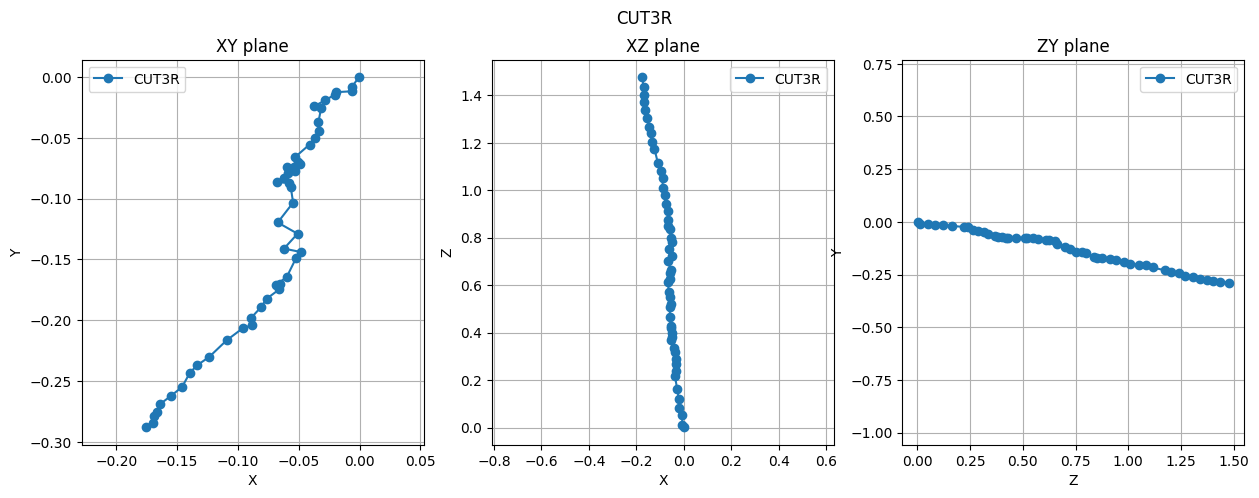

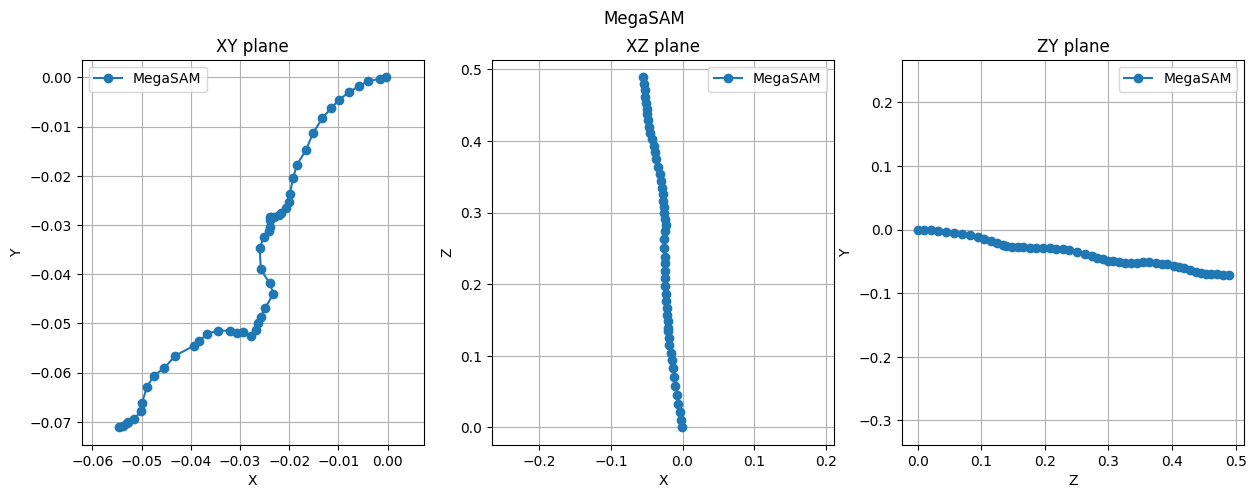

In [7]:
#CUT3R vs MegaSam
import importlib, sys
sys.path.insert(0, str(project_root / "src"))

frames_dir = case_dir /"020_frames_for_recon" / "01_walk_sparse_initial_50_full"
print(case_dir)

A, dict = load_cut3r_trace_v2(case_dir / "035_CUT3R_output" / "21" / "camera")
#Data/01_walk/035_CUT3R_output/21/camera
B = load_megasam_trace(case_dir / "036_MEGASAM_output" / f"{case_name}_sgd_cvd_hr_01.npz",frames_dir )

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(A, B, "CUT3R","MegaSAM", out_path =out_dir/"Initial_050_C_M.png" , anchor_index=0)
print("RMSE after alignment:", rmse)

# centroid-mode companion -- see notebook discussion: anchor_index=0 forces zero
# error at frame 0 and concentrates any R/s mismatch at the far end of the trace;
# centroid mode spreads it instead, so comparing the two shows whether divergence
# seen in the anchored chart is real or just where the anchor dumped the residual.
R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(A, B, "CUT3R","MegaSAM", out_path =out_dir/"Initial_050_C_M_centroid.png" , anchor_index=None)
print("RMSE (centroid):", rmse_c)

AssertionError: call set_case(case_name, experiment) first

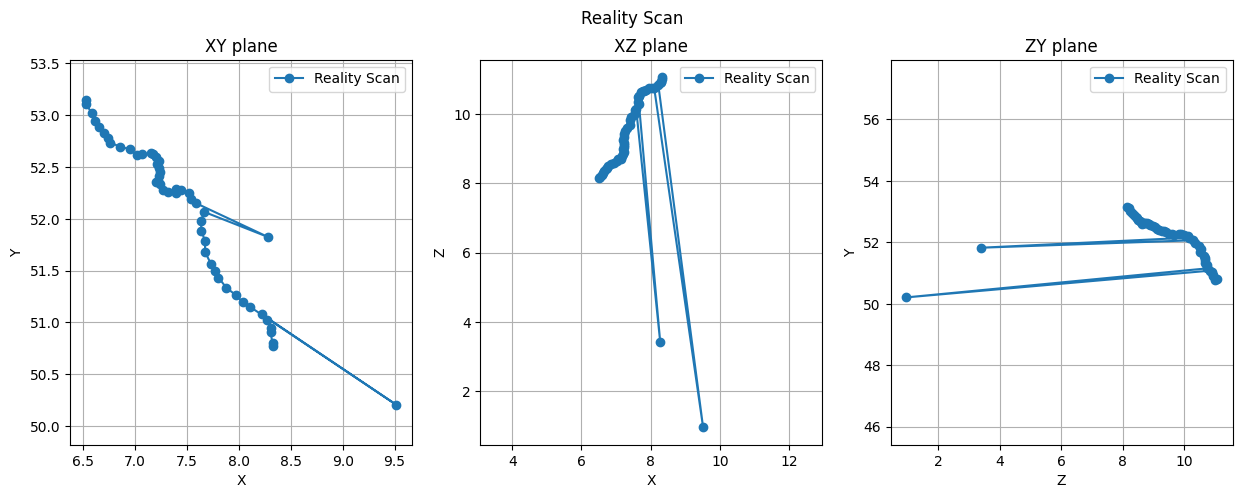

In [8]:
#COMPARE CAMERA SOLVES RS vs MEGASCAN
import sys
sys.path.insert(0, str(project_root / "src"))


Reality_scan, RS_dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05b.csv")
B = load_megasam_trace(case_dir / "036_MEGASAM_output" / f"{case_name}_sgd_cvd_hr_01.npz")
print(Reality_scan)
assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(Reality_scan, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"Initial_050_RS_M.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(Reality_scan, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"Initial_050_RS_M_centroid.png" ,anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

A,B 51 51
RMSE after alignment: 0.19353129229420415
A,B 51 51
RMSE (centroid): 0.19353129229420415


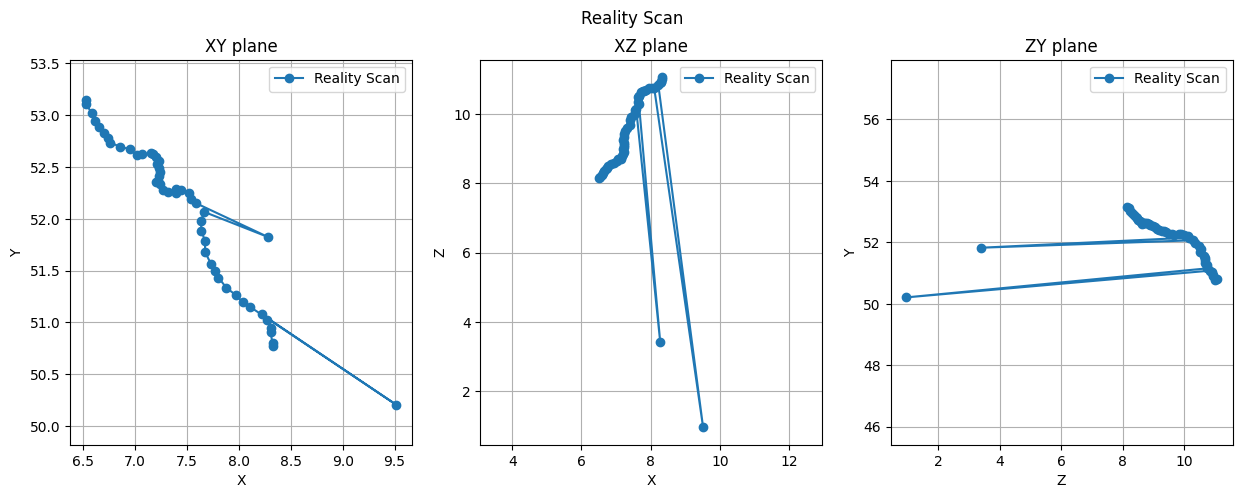

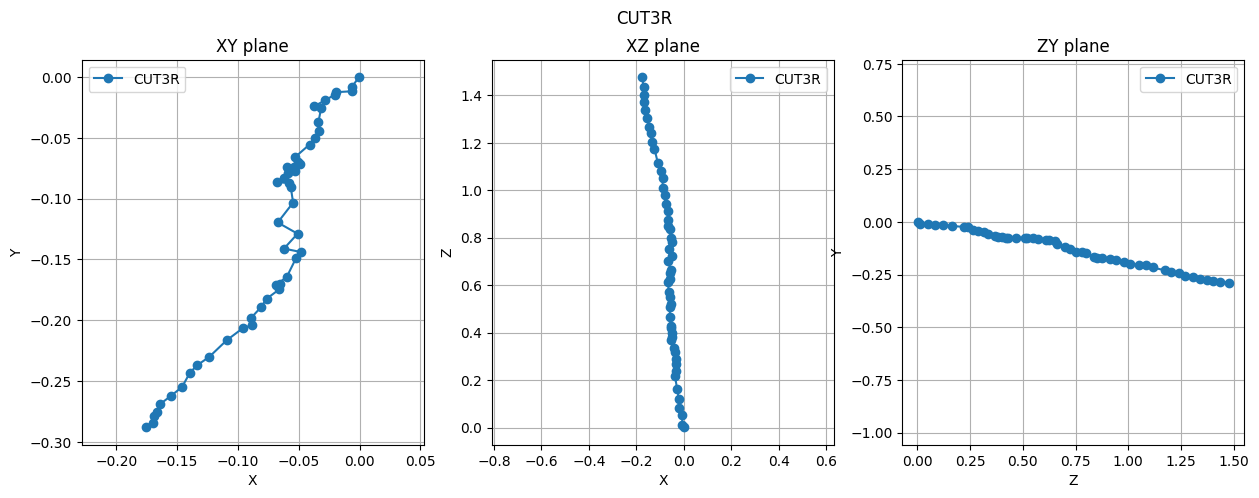

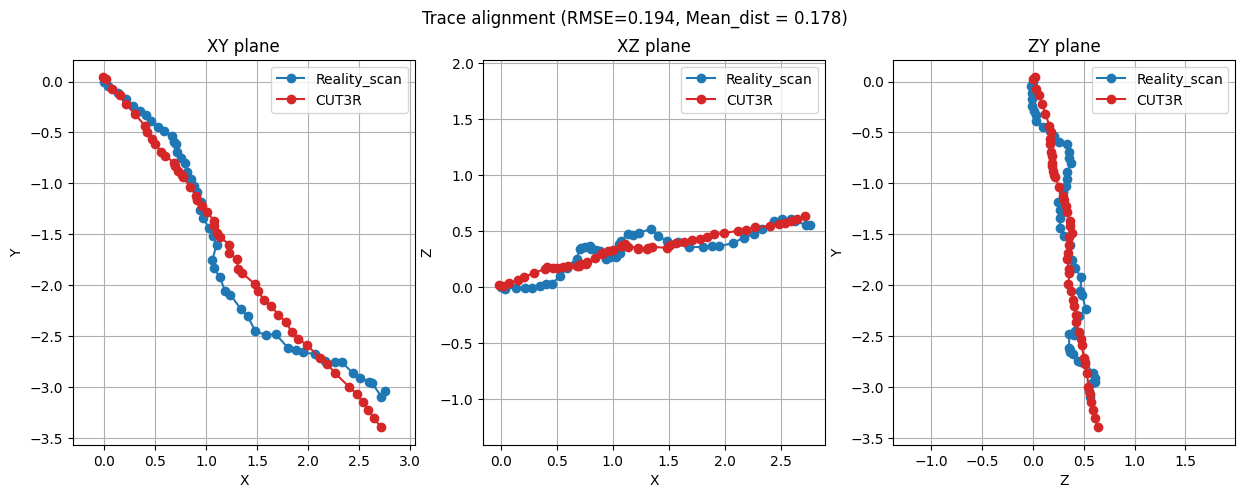

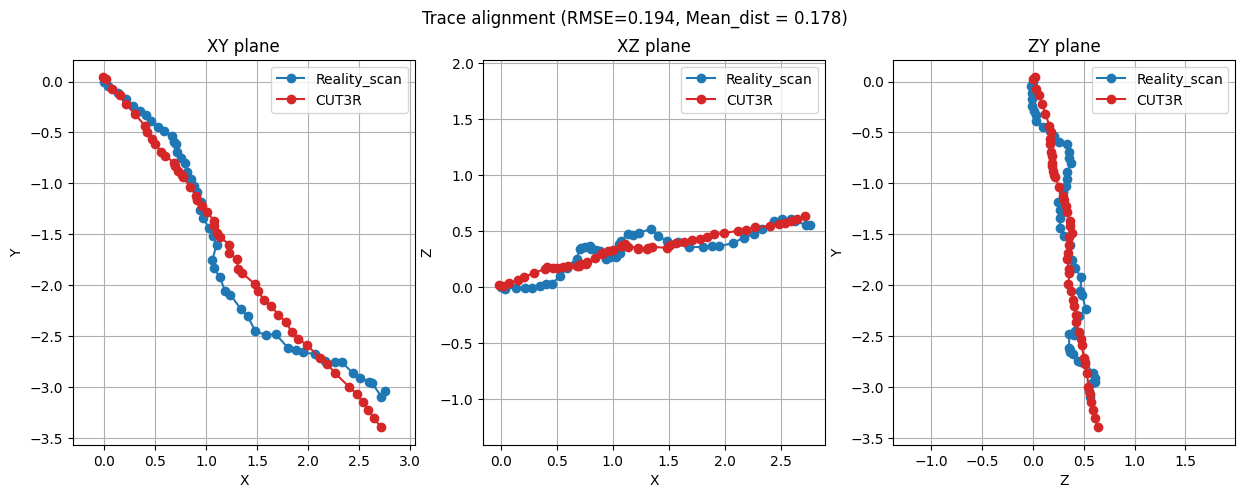

In [12]:
#COMPARE CAMERA SOLVES RS vs CUT3R
import sys
sys.path.insert(0, str(project_root / "src"))


Reality_scan, dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05b.csv")
C = load_cut3r_trace(case_dir / "035_CUT3R_output" / "21" / "camera")


R, s, t, B_aligned, rmse = umeyama_align(Reality_scan, C, "Reality_scan" , "CUT3R" , out_path =out_dir/"Initial_050_RS_C.png"  , skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(Reality_scan, C, "Reality_scan" , "CUT3R" , out_path =out_dir/"Initial_050_RS_C_centroid.png"  , skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

22/06 - moved onto FULL RES for rc and it works much better, so now for the comparisons

A)
A,B 50 50
RMSE after alignment: 4280.062543844494
A)
A,B 50 50
RMSE (centroid): 4000.8896845678432


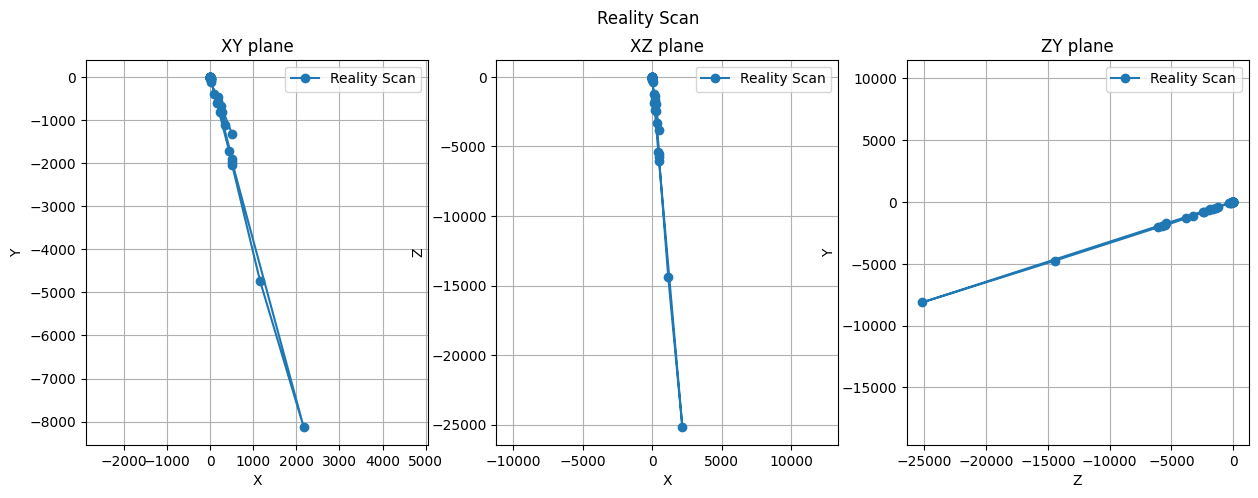

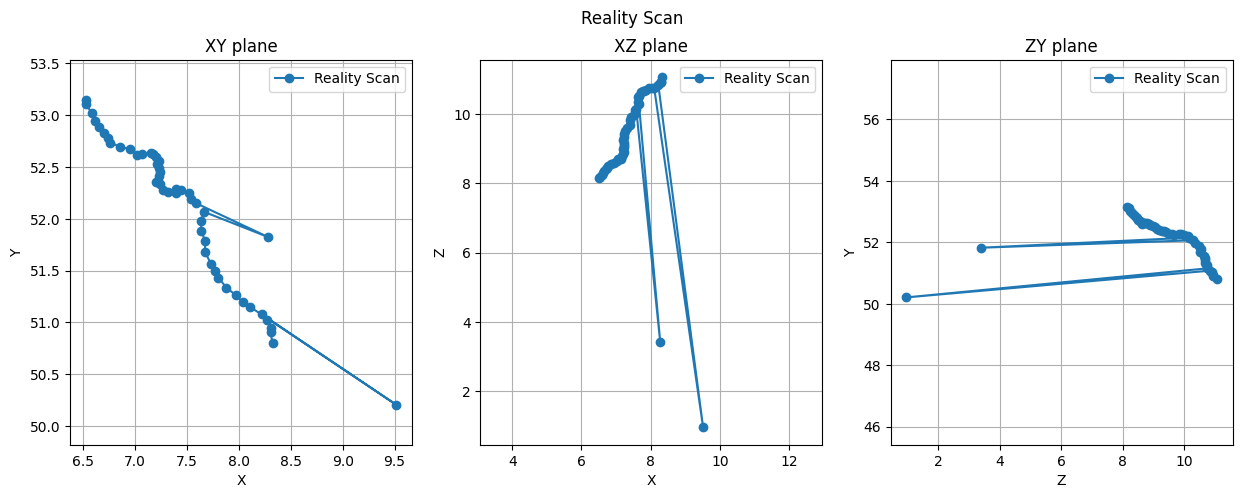

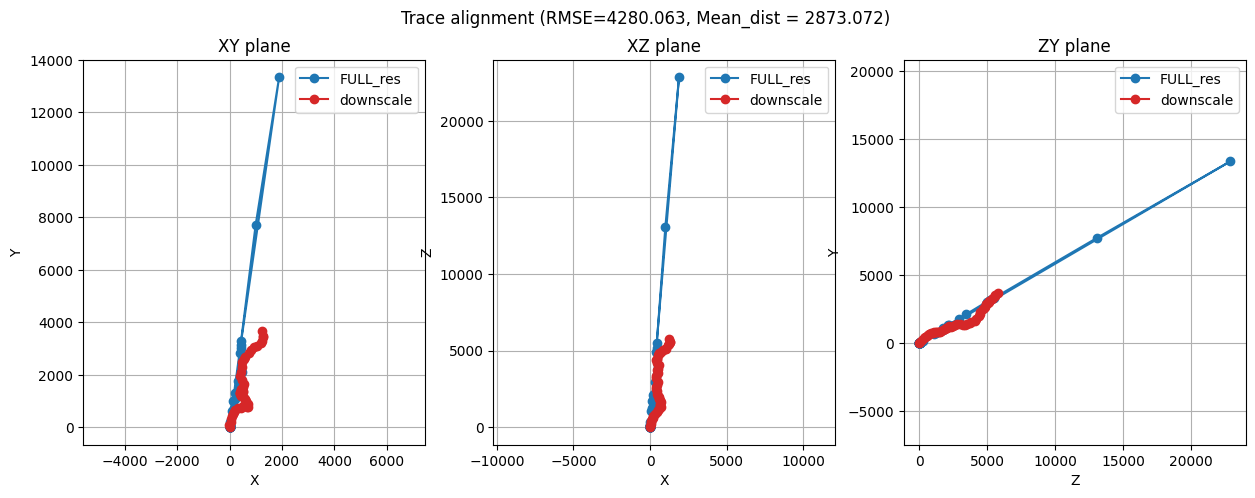

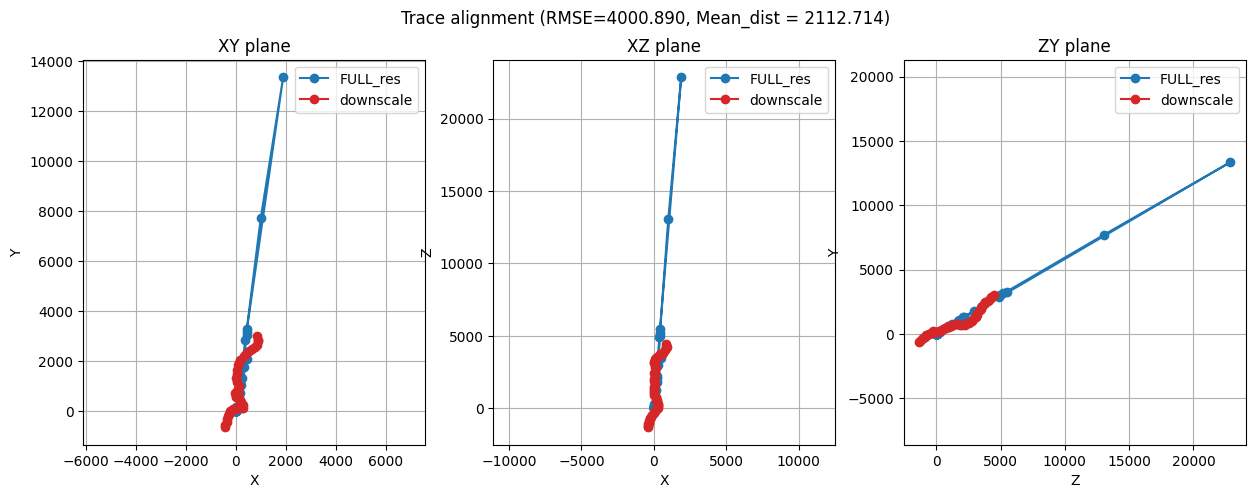

In [34]:
#RCfull vs RC 512

RS_init,dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_FULL.csv")
B,dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05e.csv")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(RS_init, B, "FULL_res","downscale", out_path =out_dir/"Initial_050_RC_RC.png" , anchor_index=0,skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS_init, B, "FULL_res","downscale", out_path =out_dir/"Initial_050_RC_RC_centroid.png" , anchor_index=None,skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

OK, after explorintg RC, 1 frame every 25 fames is working well - about 1s interval there.


50 FRAME INTERVALS:  01_walk_sparse_50_02_FULL_02

A,B 50 50
A,B 50 50
RMSE after alignment: 0.8422090740647026


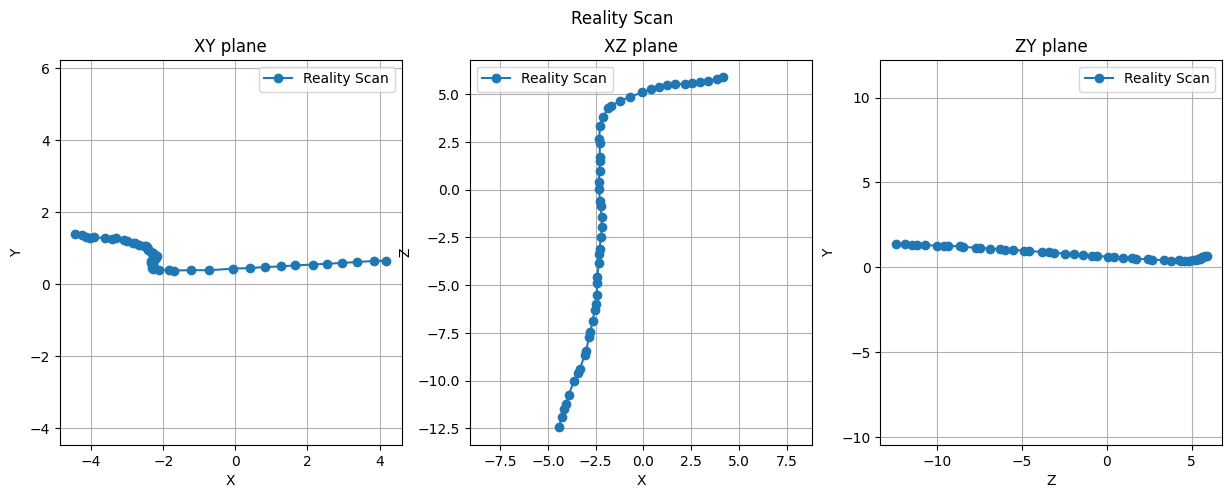

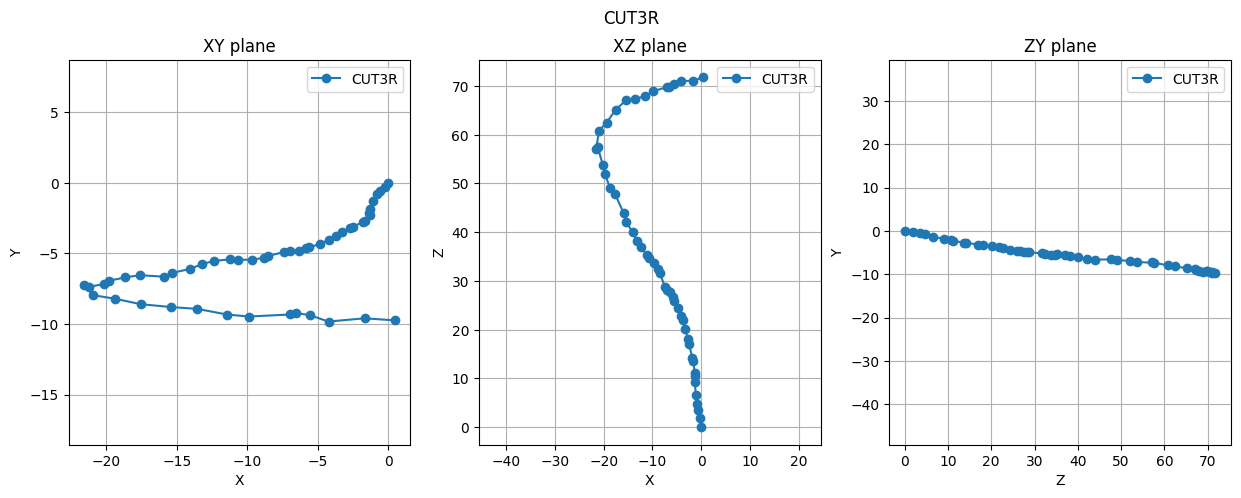

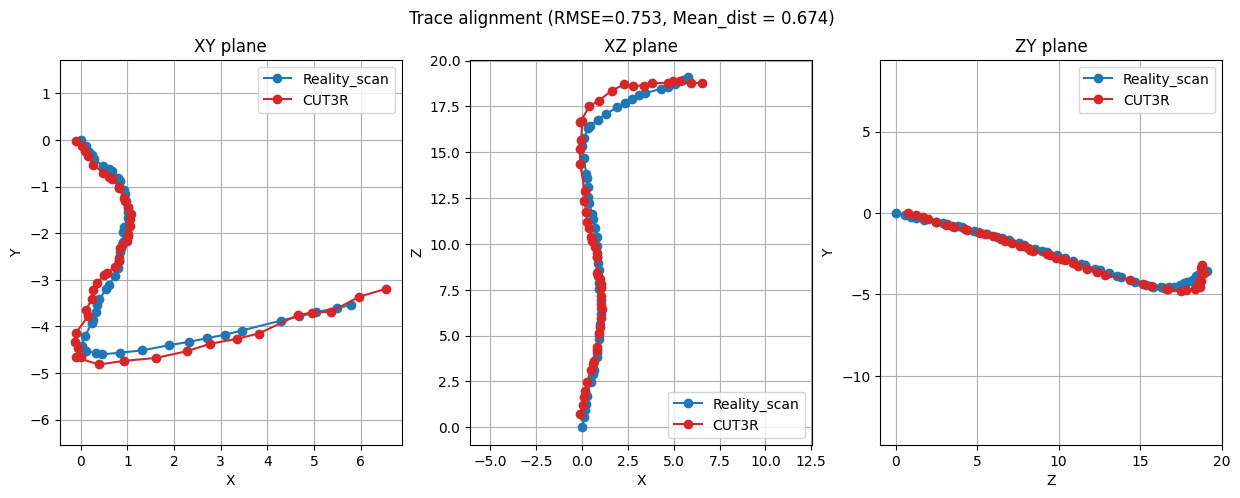

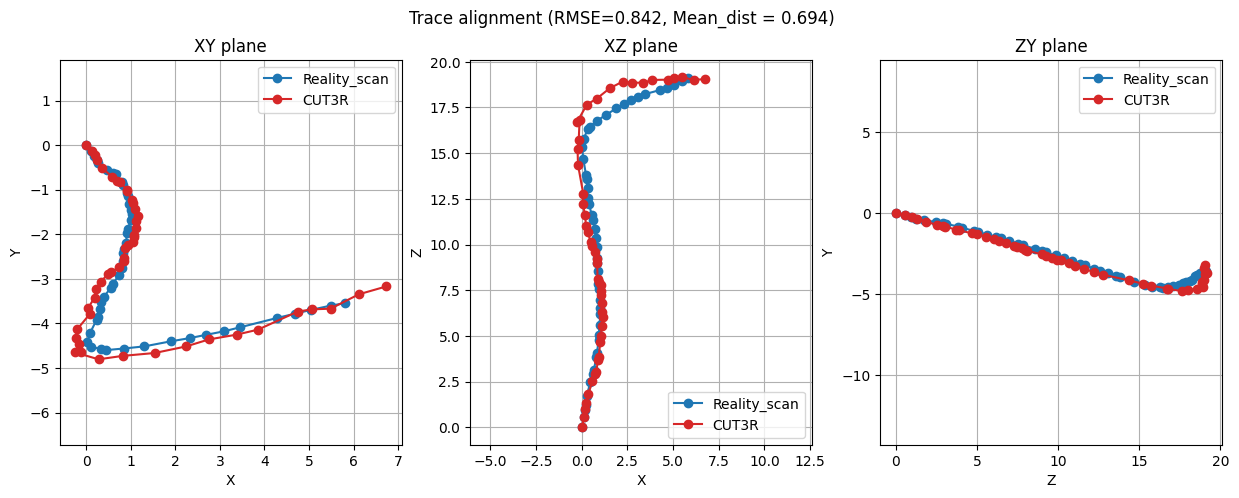

In [3]:
#COMPARE CAMERA SOLVES RS vs CUT3R
frames_for_recon_dir = (case_dir / "020_frames_for_recon" / "01_walk_sparse_50_02_full")
RS, RS_dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_sparse_50_02_full_02" /"01_walk_sparse_50_02_FULL_02.csv")
B = load_cut3r_trace(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")
R, s, t, B_aligned, rmse = umeyama_align(RS, B, "Reality_scan" , "CUT3R" , out_path =out_dir/"01_walk_sparse_50_02_RS_C.png"  , skip_indices=(31,44))
R, s, t, B_aligned, rmse = umeyama_align_anchor(RS, B, label_A="Reality_scan" , label_B="CUT3R" , out_path =out_dir/"01_walk_sparse_50_02_RS_C_anchored.png"  , skip_indices=(31,44))

print("RMSE after alignment:", rmse)

A,B 50 50
A,B 50 50
RMSE after alignment: 2.9776215671192188


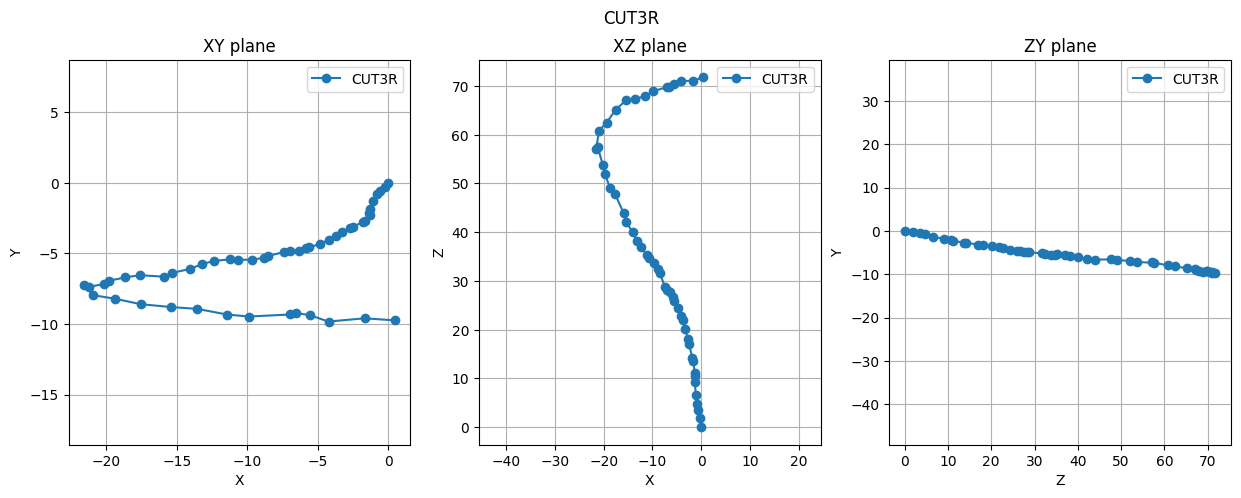

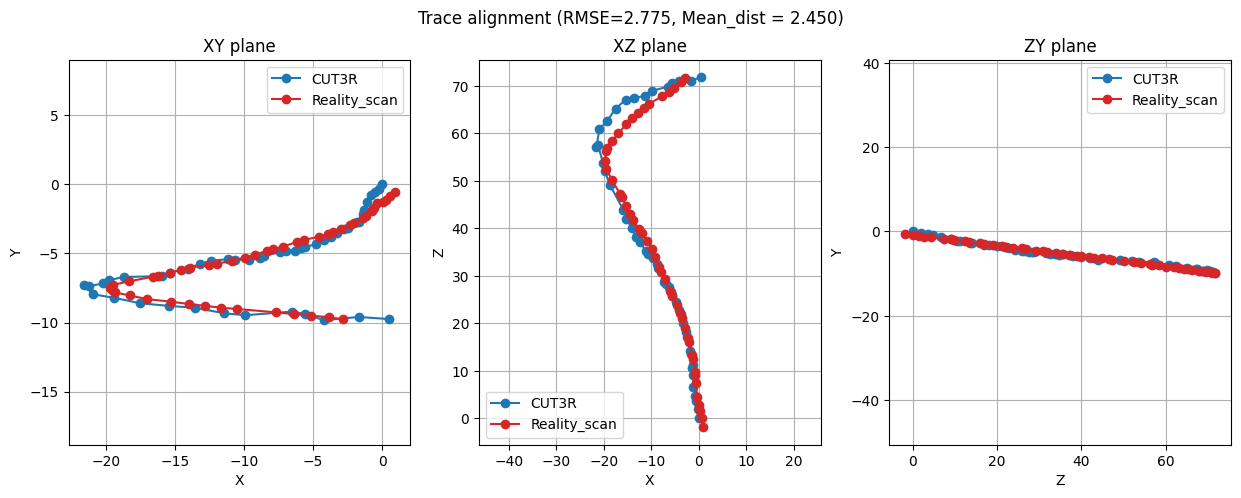

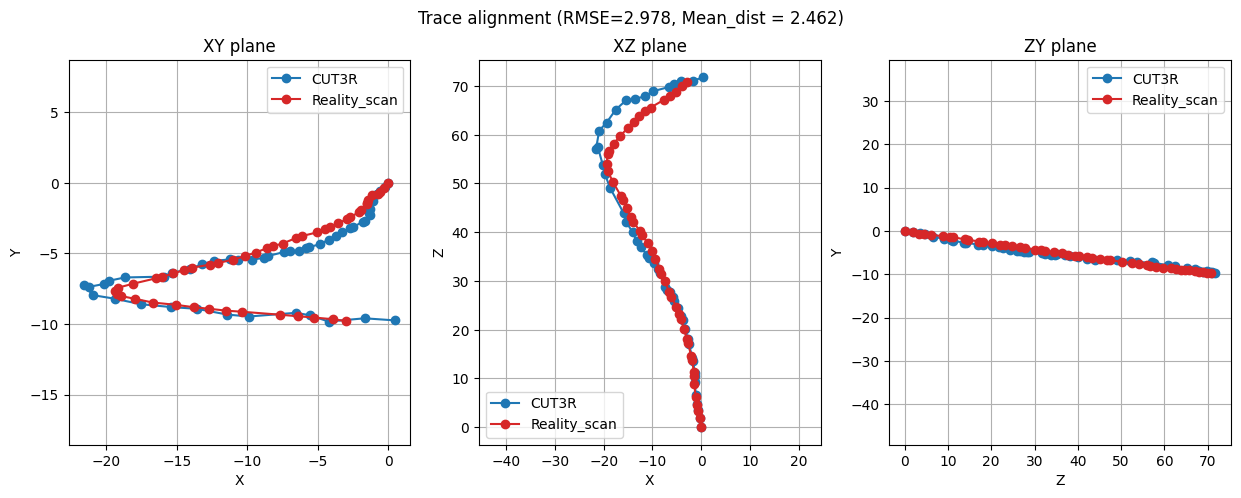

In [5]:
#COMPARE CAMERA SOLVES CUT3R vs RS 

A = load_cut3r_trace(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(A, RS, "CUT3R", "Reality_scan"  , out_path =out_dir/"01_walk_sparse_50_02_RS_C.png"  , skip_indices=(31,44))
R, s, t, B_aligned, rmse = umeyama_align_anchor(A, RS, "CUT3R", "Reality_scan" , out_path =out_dir/"01_walk_sparse_50_02_RS_C_anchored.png"  , skip_indices=(31,44))

print("RMSE after alignment:", rmse)

A,B 50 50
RMSE after alignment: 1.1530304030037655
A,B 50 50
A,B 50 50
A,B 50 50
RMSE (centroid): 1.2539556163775907


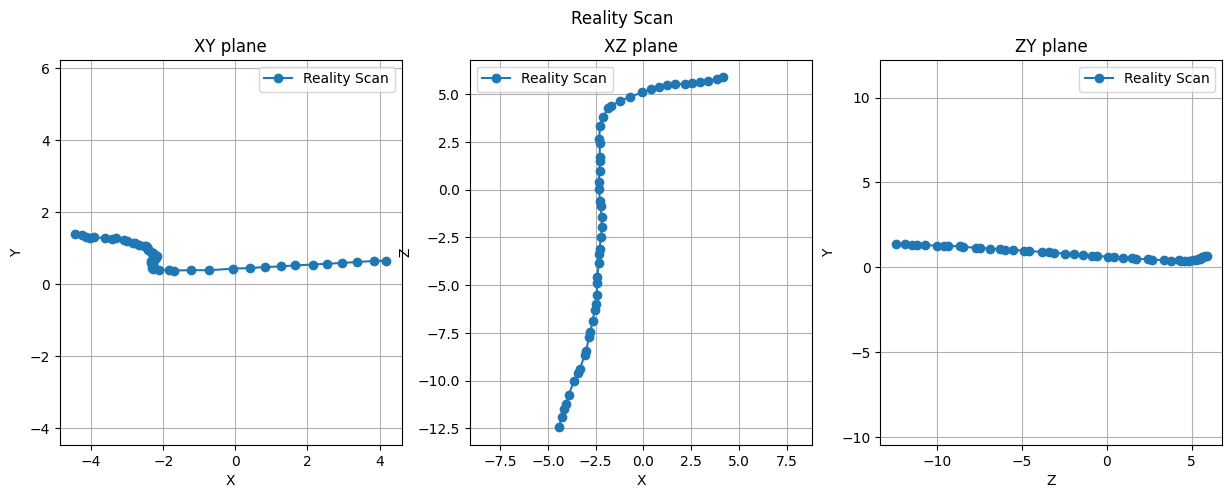

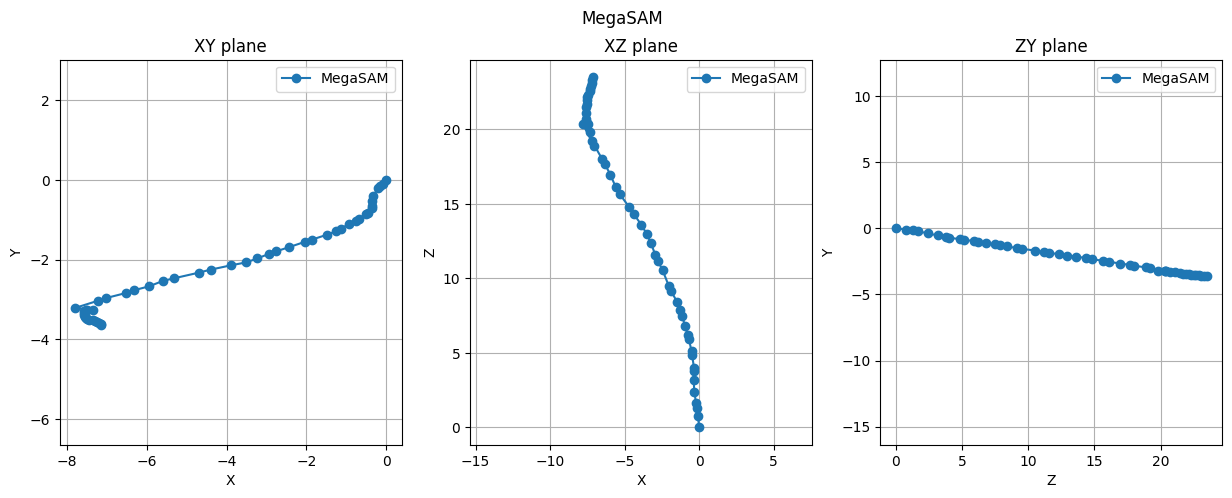

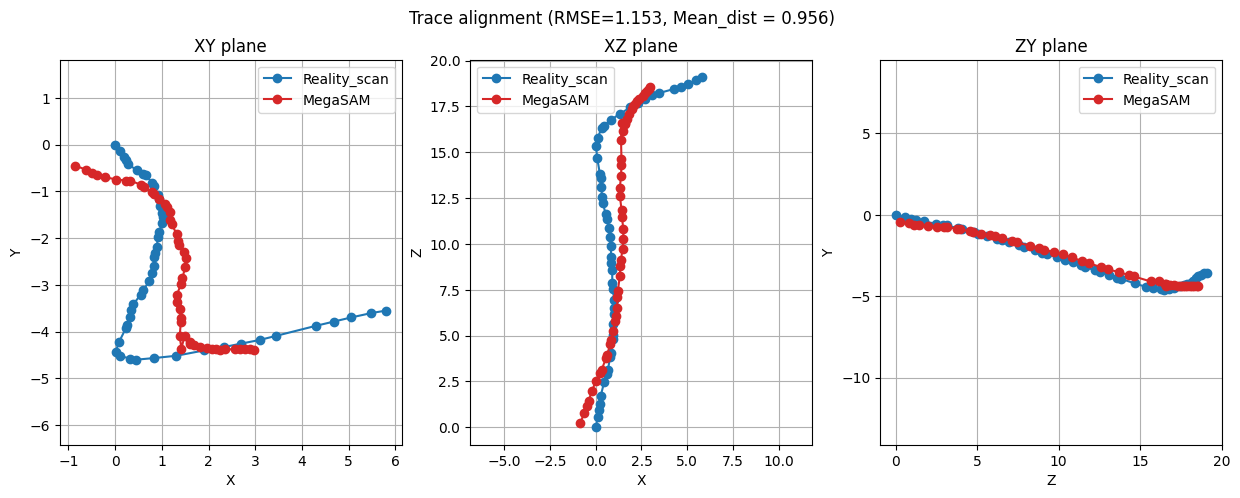

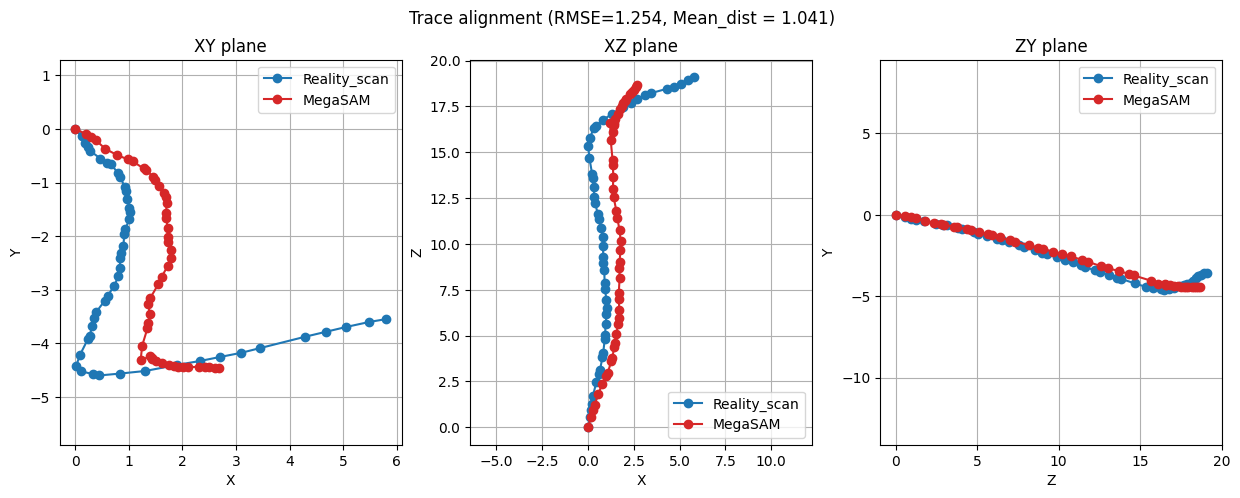

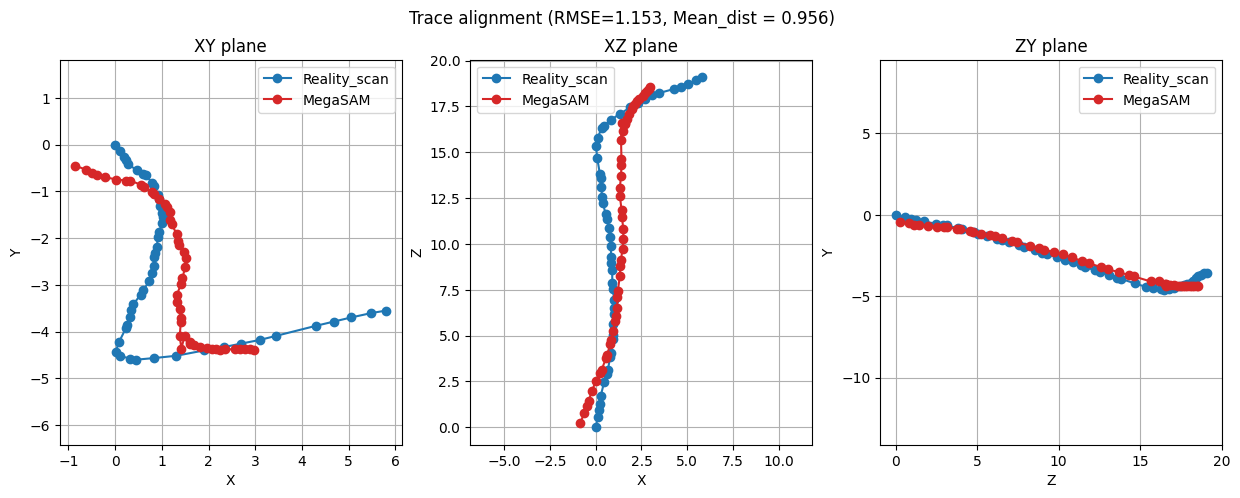

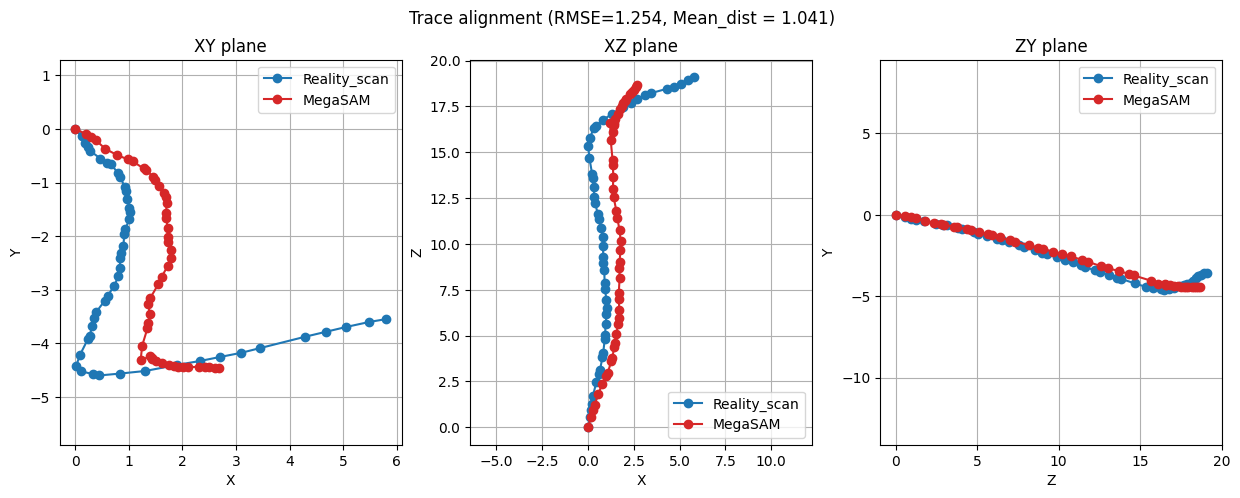

In [11]:
#COMPARE CAMERA SOLVES RS vs MEGASCAN


RS, dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_sparse_50_02_full_02" /"01_walk_sparse_50_02_FULL_02.csv")
B,dict = load_megasam_trace(case_dir / "036_MEGASAM_output" / "01_walk_sparse_50_02_full" / f"{case_name}_sgd_cvd_hr.npz",frames_for_recon_dir)

assert RS.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(RS, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_M.png" , skip_indices=(31,44))
print("RMSE after alignment:", rmse)
R, s, t, B_aligned, rmse = umeyama_align_anchor(RS, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_M.png" ,skip_indices=(31,44))

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_M_centroid.png" , skip_indices=(31,44))
R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align_anchor(RS, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_M_centroid.png" , skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

{0: array([-8.8044675e-05, -7.8559271e-04,  2.1755523e-03], dtype=float32), 1: array([-0.21555652, -0.31602678,  1.9556043 ], dtype=float32), 2: array([-0.5577746, -0.5407596,  3.5632577], dtype=float32), 3: array([-0.78613186, -0.7759314 ,  4.7450104 ], dtype=float32), 4: array([-1.1218133, -1.3093321,  6.631251 ], dtype=float32), 5: array([-1.2854823, -1.8699661,  9.202408 ], dtype=float32), 6: array([-1.3640234, -2.1397917, 10.605414 ], dtype=float32), 7: array([-1.2999219, -2.251887 , 11.16647  ], dtype=float32), 8: array([-1.6686344, -2.6997046, 13.603968 ], dtype=float32), 9: array([-1.8172252, -2.7401395, 14.168367 ], dtype=float32), 10: array([-2.4875588, -3.142905 , 17.031015 ], dtype=float32), 11: array([-2.7517614, -3.22972  , 18.111282 ], dtype=float32), 12: array([-3.2565374, -3.4950907, 20.09551  ], dtype=float32), 13: array([-3.7148368, -3.7905815, 21.906263 ], dtype=float32), 14: array([-4.227147, -4.02184 , 22.805548], dtype=float32), 15: array([-4.8132133, -4.326014 ,

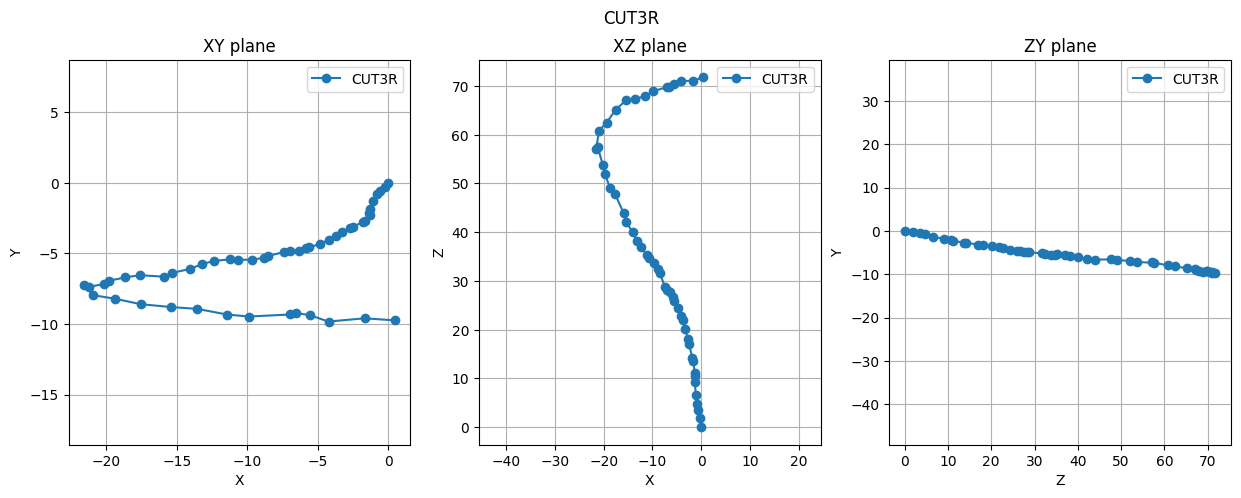

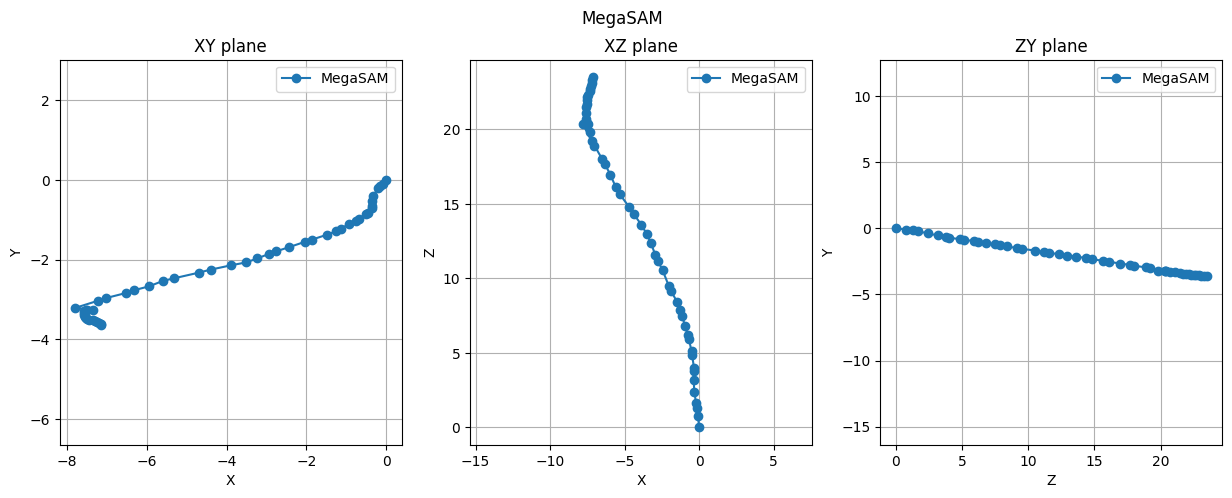

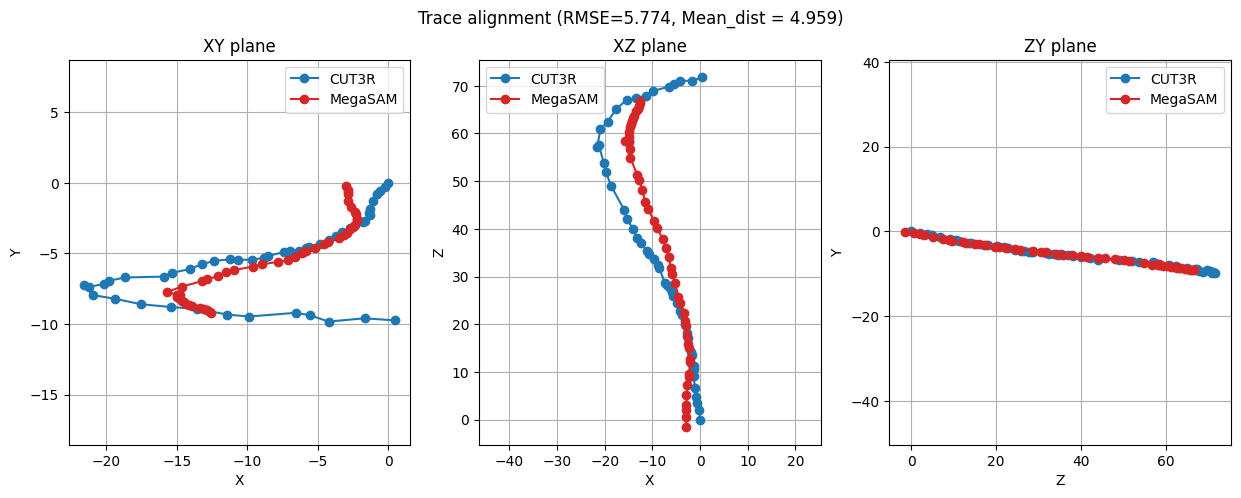

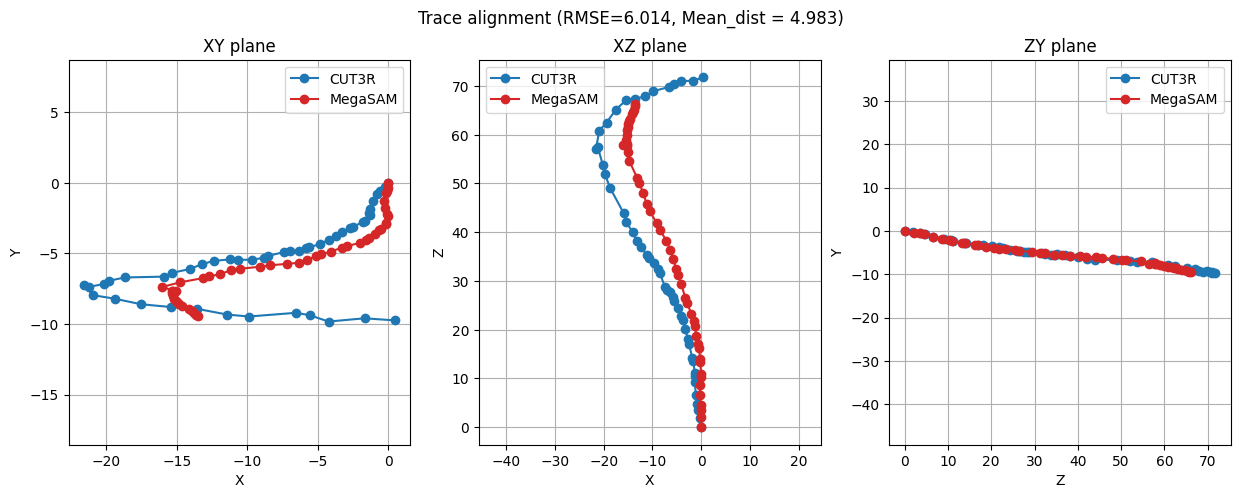

In [12]:
#COMPARE CAMERA SOLVES CUT3R vs MEGASCAN

CUT, CUT_dict = load_cut3r_trace_v2(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")
M, M_dict = load_megasam_trace(case_dir / "036_MEGASAM_output" / "01_walk_sparse_50_02_full" / f"{case_name}_sgd_cvd_hr.npz", frames_for_recon_dir)

assert CUT.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(CUT, M, "CUT3R" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_C_M.png" ,skip_indices=(31,44))
R, s, t, B_aligned, rmse = umeyama_align_anchor(CUT, M, "CUT3R" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_C_M.png" ,skip_indices=(31,44))

print("RMSE after alignment:", rmse)



A,B 50 50
RMSE after alignment: 0.12872824296778818
A,B 50 50
RMSE (centroid): 0.12872824296778818


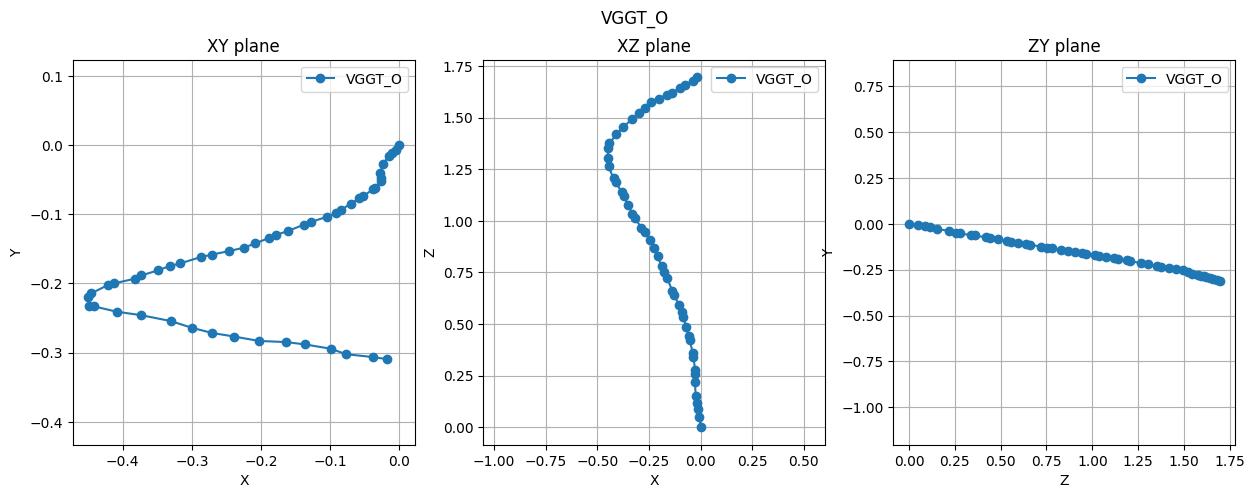

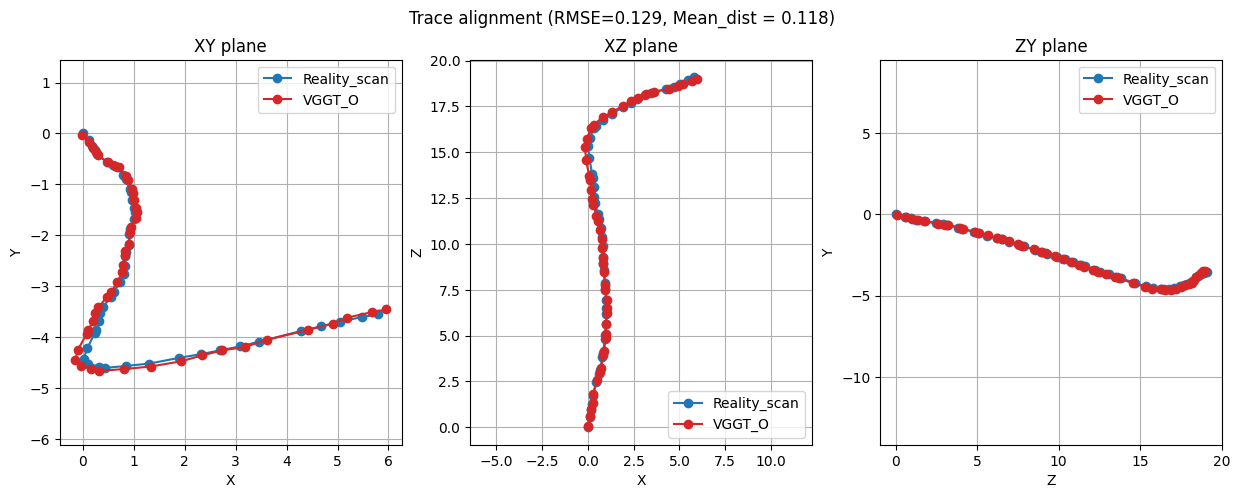

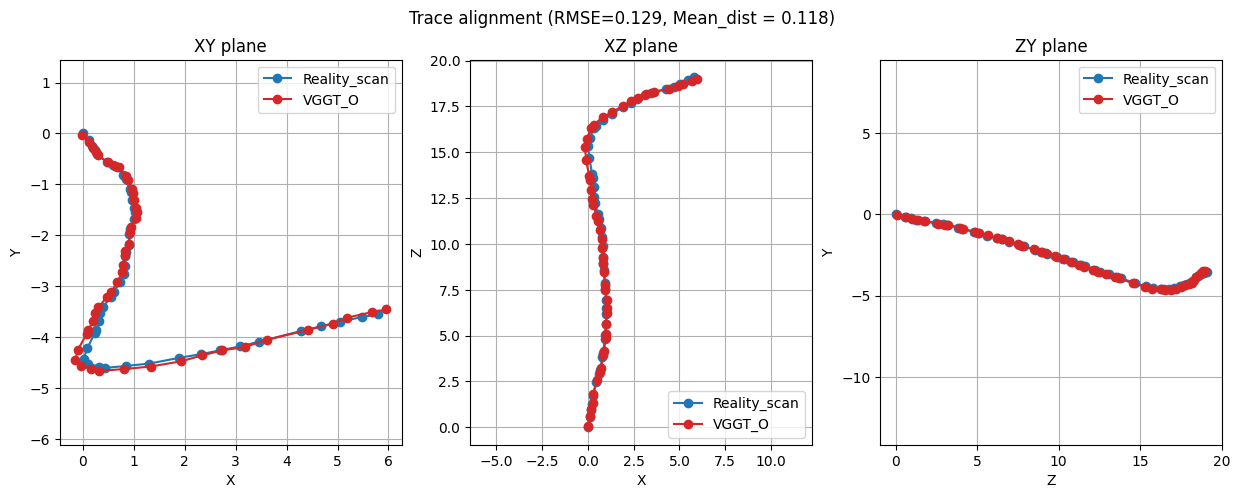

In [17]:
VGGTO,VGGTO_dict  = load_VGGT_O_trace((case_dir / "035_VGGT_O_output" / "01_walk_sparse_50_02_full" / "predictions.npz"), frames_dir = frames_for_recon_dir)
R, s, t, B_aligned, rmse = umeyama_align(RS,VGGTO , "Reality_scan" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_VGGTO.png" , skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS,VGGTO , "Reality_scan" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_VGGTO_centroid.png" , skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

A,B 50 50
RMSE after alignment (lingbot vs VGGT_O): 0.05313334660874999
A,B 50 50
RMSE (centroid, lingbot vs VGGT_O): 0.05313334660874999
A,B 50 50
RMSE after alignment (RS vs lingbot): 0.28094601398129243
A,B 50 50
RMSE (centroid, RS vs lingbot): 0.28094601398129243


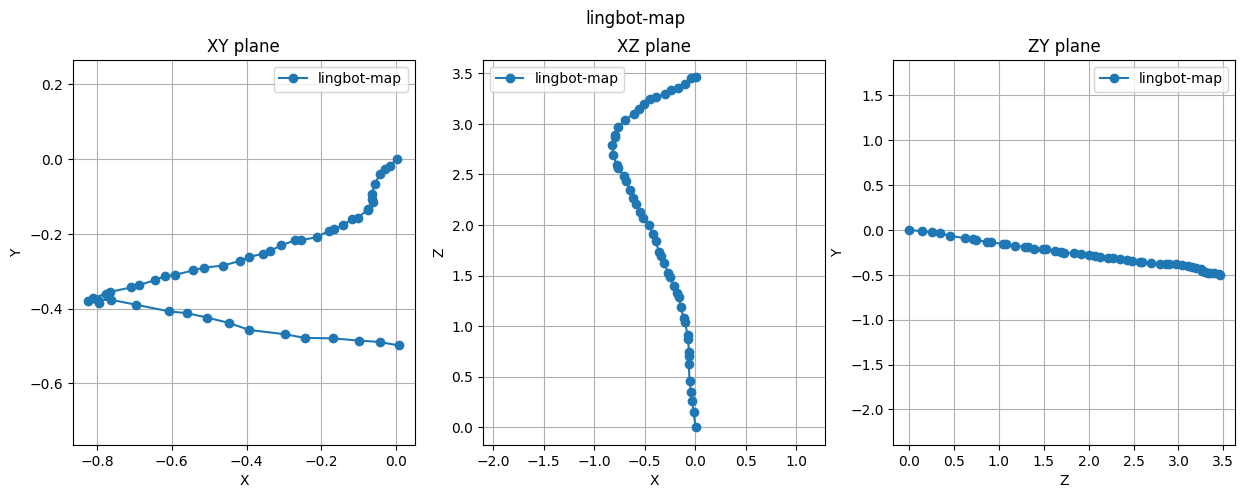

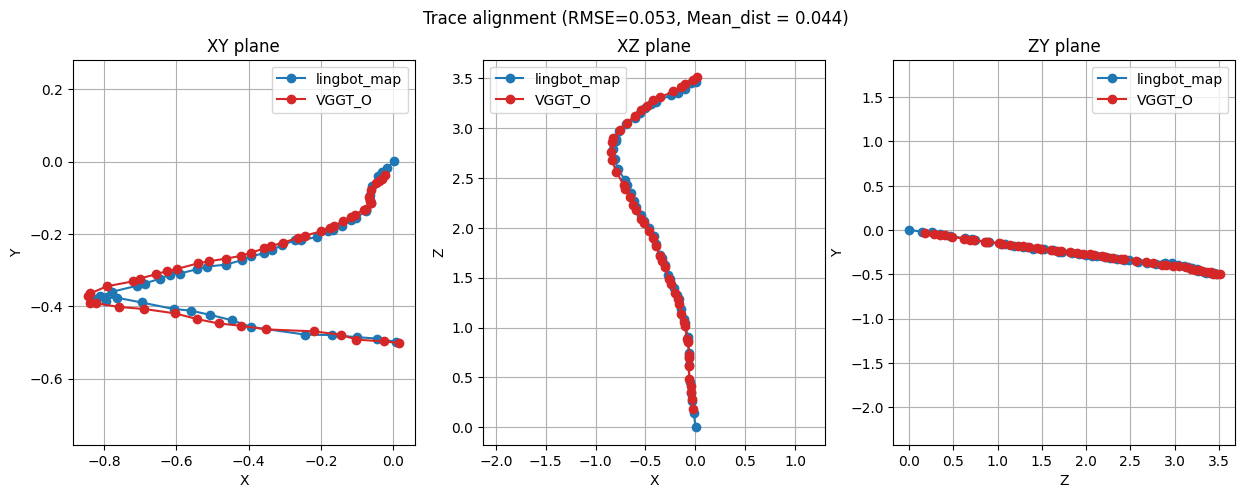

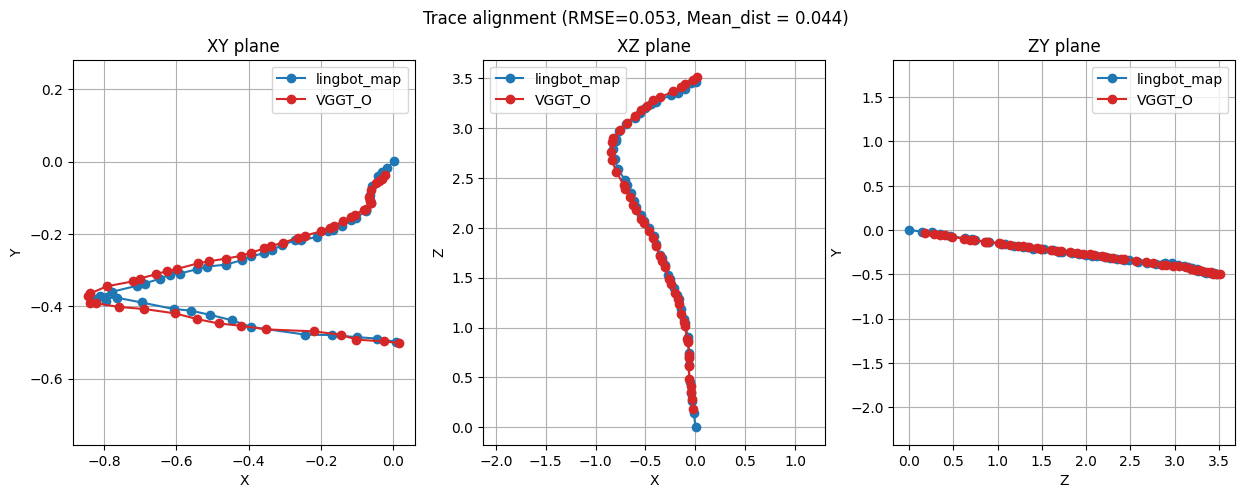

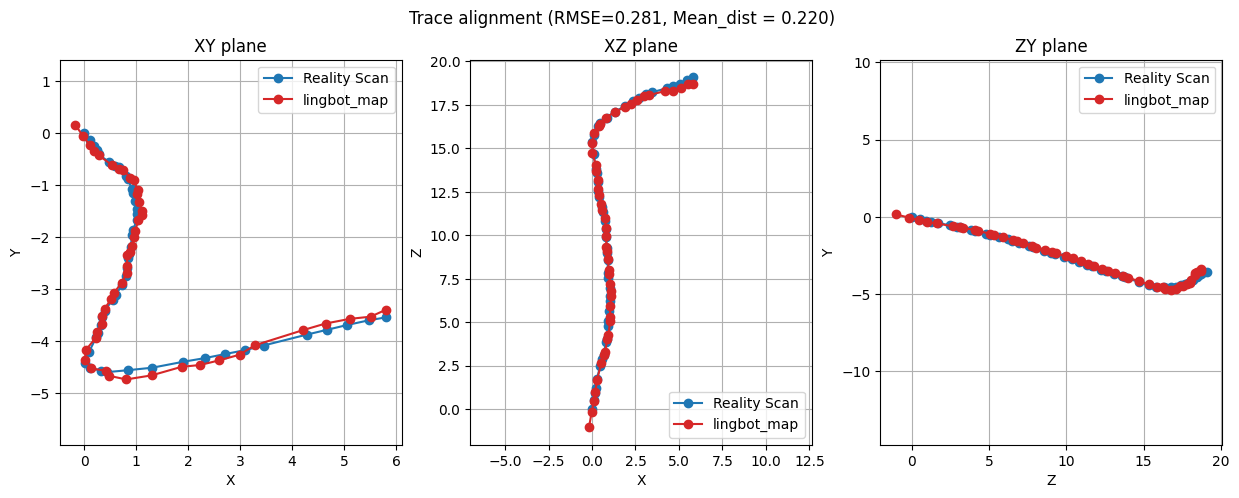

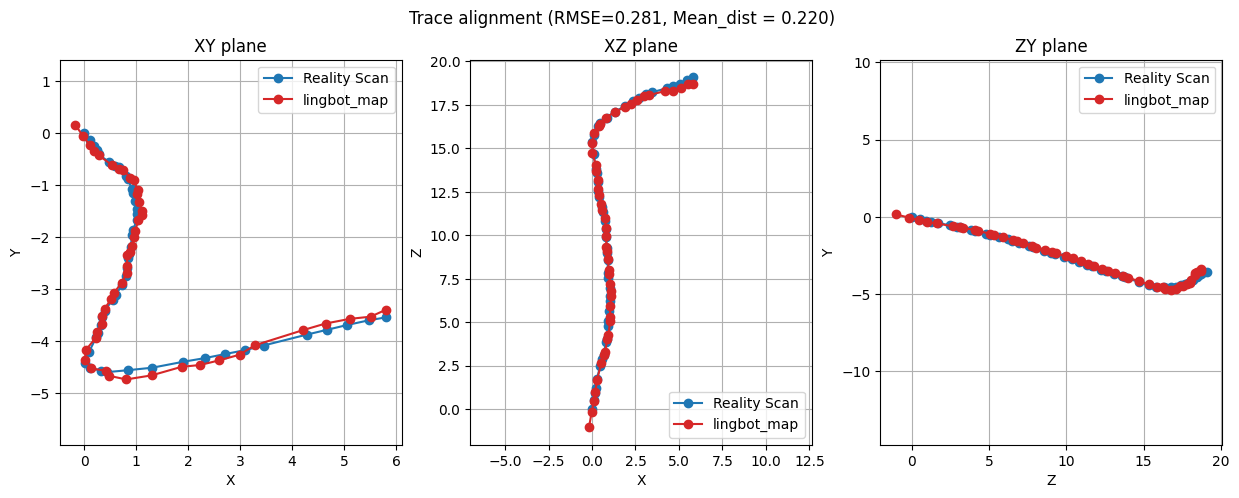

In [ ]:
from F_post_recon_processing import load_lingbot_map_trace
lb, lb_dict = load_lingbot_map_trace(case_dir / "036_lingbot_map_output" / "01_walk_sparse_50_02_full")
R, s, t, B_aligned, rmse = umeyama_align(lb, VGGTO , "lingbot_map" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_lingbot_VGGTO.png" , skip_indices=(31,44))
print("RMSE after alignment (lingbot vs VGGT_O):", rmse)
R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(lb, VGGTO , "lingbot_map" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_lingbot_VGGTO_centroid.png" , skip_indices=(31,44))
print("RMSE (centroid, lingbot vs VGGT_O):", rmse_c)
R, s, t, B_aligned, rmse = umeyama_align(RS, lb,  "Reality Scan" , "lingbot_map" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_lingbot.png" , skip_indices=(31,44))
print("RMSE after alignment (RS vs lingbot):", rmse)
R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS, lb,  "Reality Scan" , "lingbot_map" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_lingbot_centroid.png" , skip_indices=(31,44))
print("RMSE (centroid, RS vs lingbot):", rmse_c)

BRING IN THE GPS SIGNALS AND REPEAT!

{0: array([0.00264051, 0.00064561, 0.00030357], dtype=float32), 1: array([-0.01712869, -0.0171351 ,  0.14650375], dtype=float32), 2: array([-0.03064941, -0.02719747,  0.26027167], dtype=float32), 3: array([-0.04248608, -0.03930487,  0.34761196], dtype=float32), 4: array([-0.0575142 , -0.06684476,  0.45758882], dtype=float32), 5: array([-0.06524369, -0.09331785,  0.6287832 ], dtype=float32), 6: array([-0.06470182, -0.10572907,  0.70699227], dtype=float32), 7: array([-0.0606844 , -0.1133358 ,  0.74558455], dtype=float32), 8: array([-0.07560375, -0.13352433,  0.8727783 ], dtype=float32), 9: array([-0.07620183, -0.13583279,  0.90800977], dtype=float32), 10: array([-0.10255497, -0.15661782,  1.0434142 ], dtype=float32), 11: array([-0.11698906, -0.16041365,  1.0808265 ], dtype=float32), 12: array([-0.14286192, -0.1766235 ,  1.1843638 ], dtype=float32), 13: array([-0.16582987, -0.18764162,  1.2863629 ], dtype=float32), 14: array([-0.1805353 , -0.19171473,  1.3284825 ], dtype=float32), 15: arr

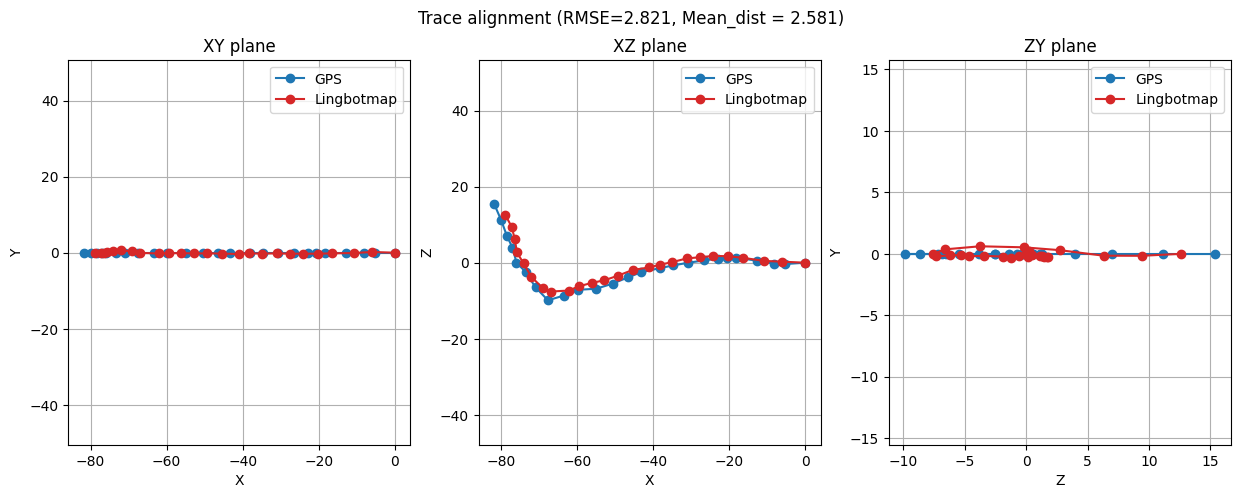

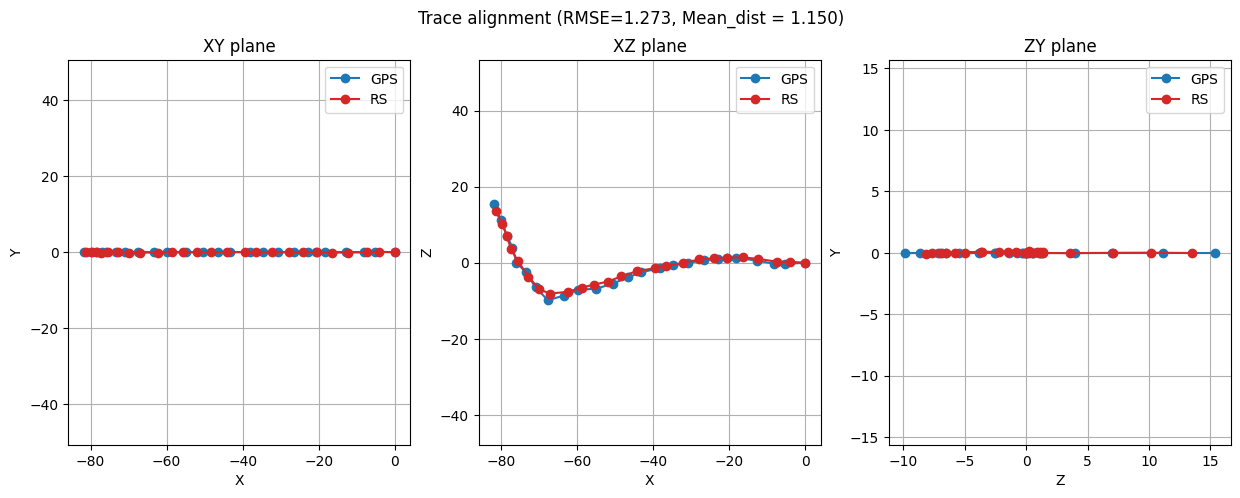

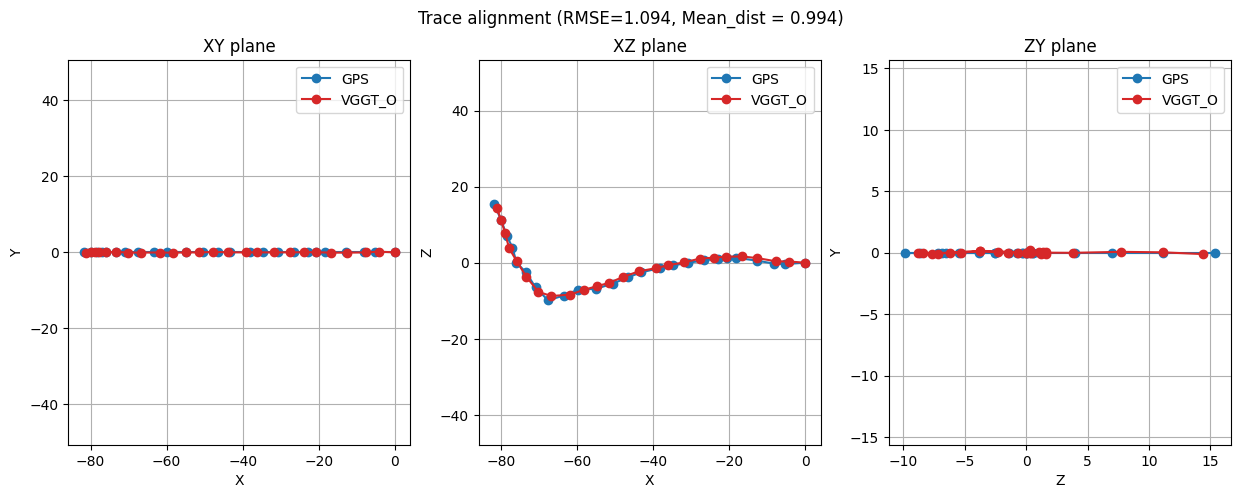

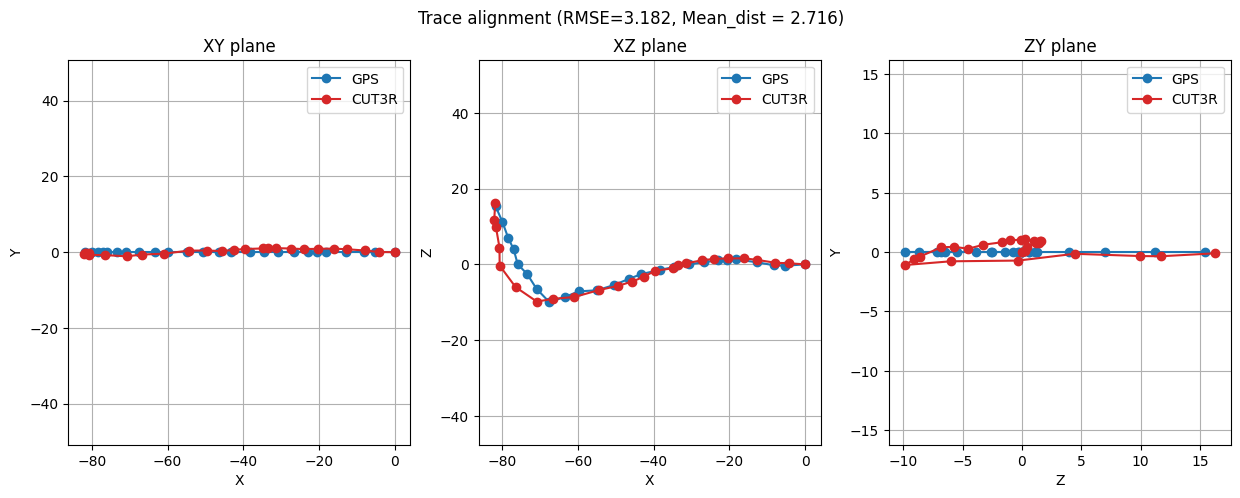

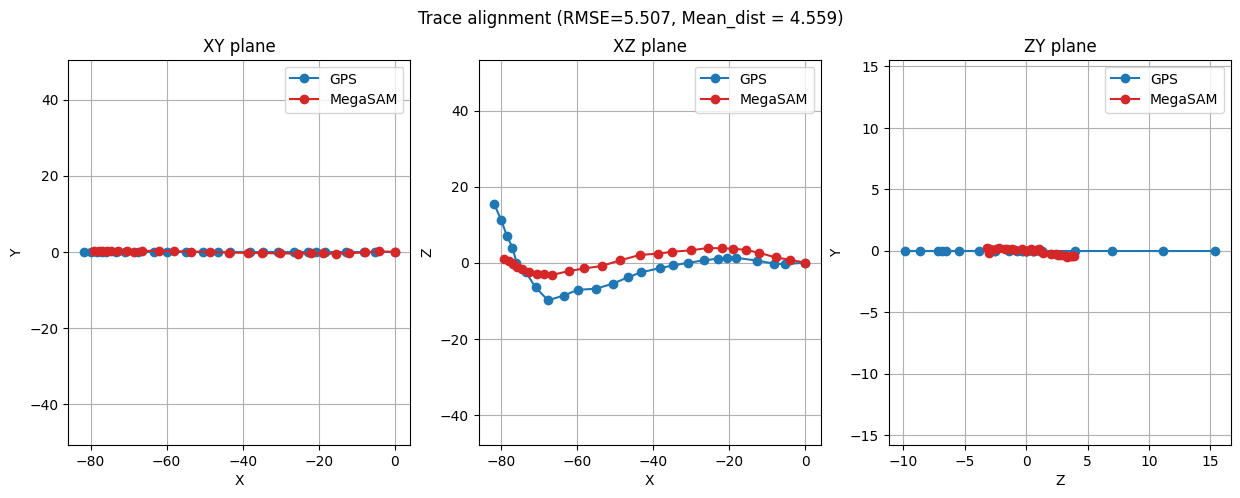

In [23]:
#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 
#get lat lon positions
#get transforms to convert other things too
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags_50_02.csv"
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
csv_path_pose = lb_dict
print(csv_path_pose)
lb_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, lb_dict, Source = "Lingbotmap" )
RS_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, RS_dict, Source = "RS" )
VGGT_O_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, VGGTO_dict, Source = "VGGT_O" )
CUT_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, CUT_dict, Source = "CUT3R" )
M_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, M_dict, Source = "MegaSAM" )


A,B 25 25
A,B 25 25
A,B 25 25
A,B 25 25
A,B 25 25
| technique    |   rmse |   mean_dist |   n_points |   trajectory_length |   spatial_extent |   rmse_cm_per_m |
|:-------------|-------:|------------:|-----------:|--------------------:|-----------------:|----------------:|
| VGGT_O       |  1.094 |       0.994 |         25 |               98.81 |           26.547 |           1.107 |
| Reality_Scan |  1.273 |       1.15  |         25 |               98.81 |           26.547 |           1.289 |
| lingbot_map  |  2.821 |       2.581 |         25 |               98.81 |           26.547 |           2.854 |
| CUT3R        |  3.182 |       2.716 |         25 |               98.81 |           26.547 |           3.22  |
| MegaSAM      |  5.507 |       4.559 |         25 |               98.81 |           26.547 |           5.573 |


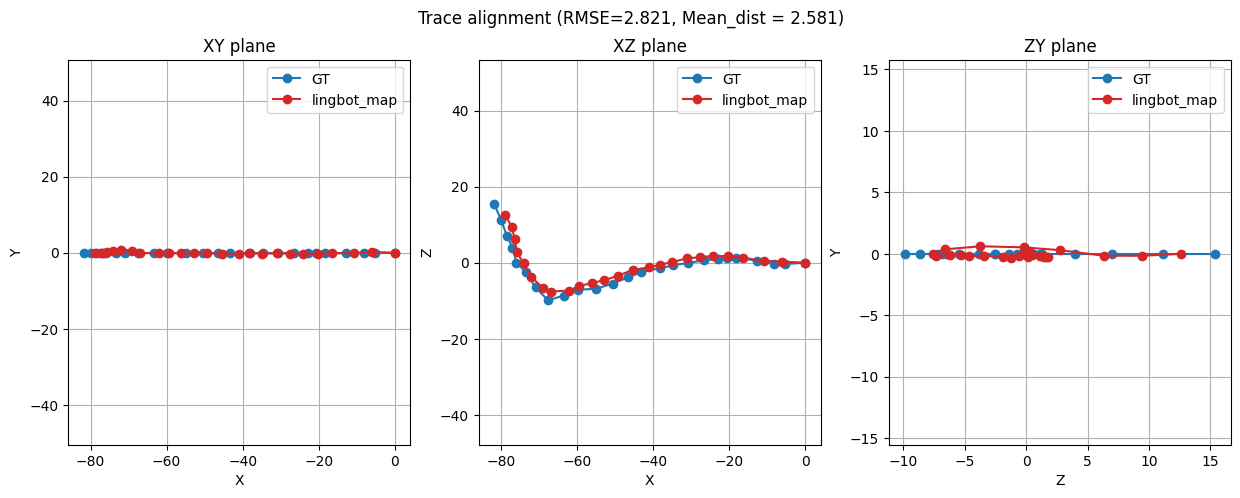

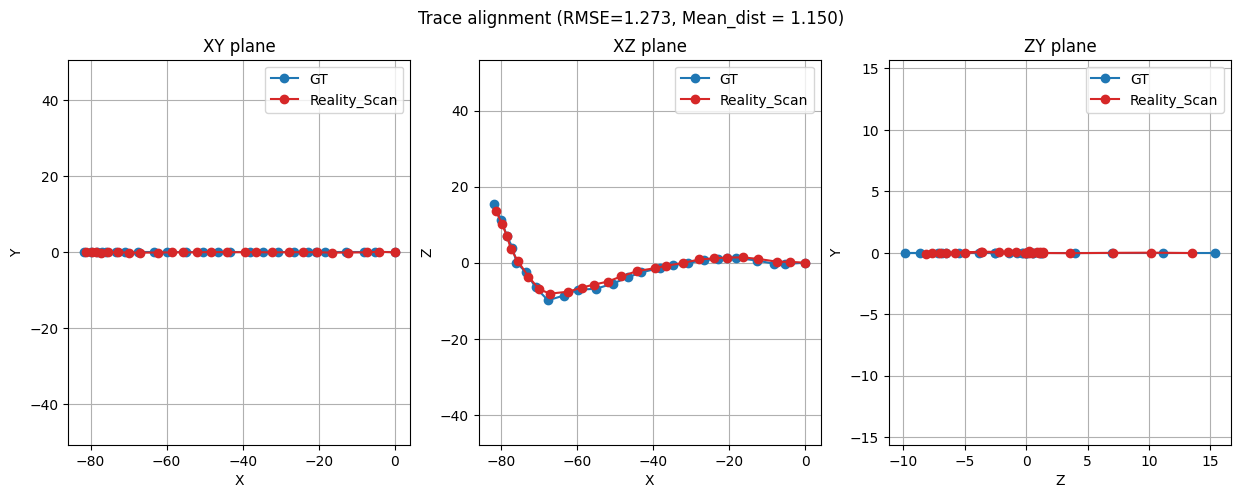

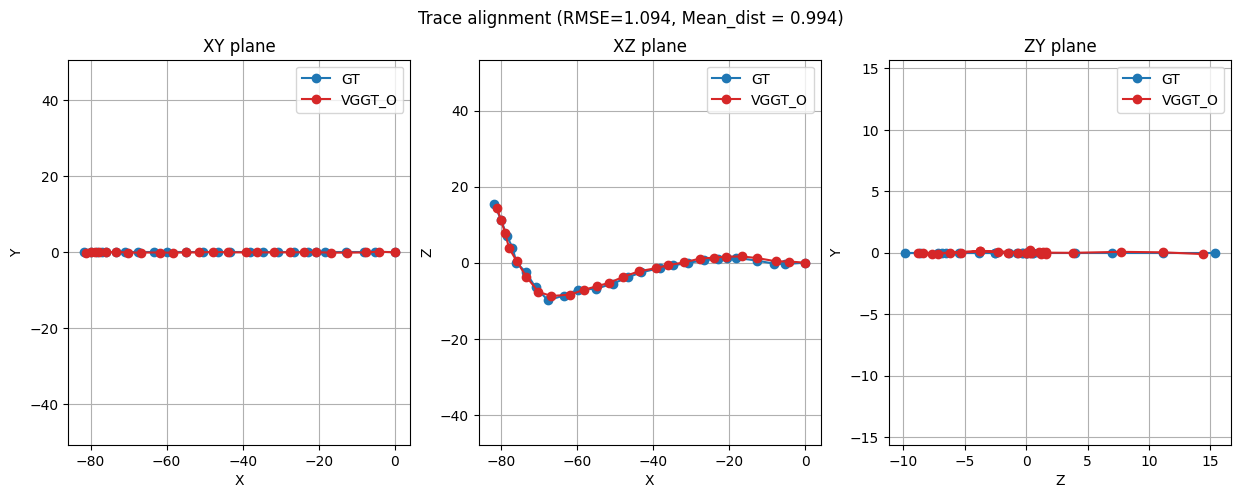

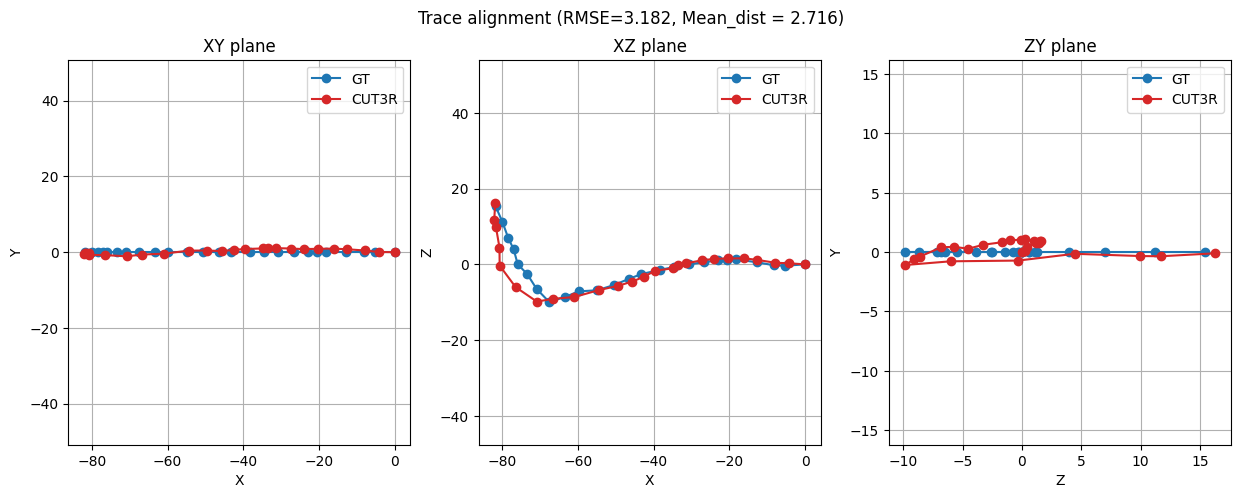

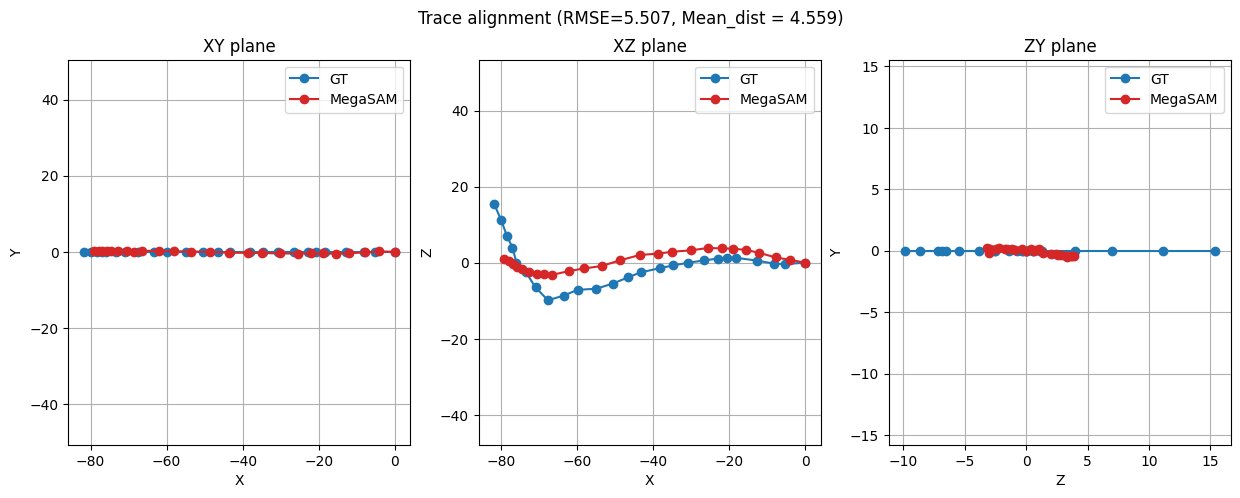

In [26]:
from G_transforms_alignments import umeyama_align
from Q_Metric_georeferencing import GPS_camerapose_matcher
from Q_GPS_processing import csv_to_GPS_dict
import numpy as np
import pandas as pd

GPS_dict = csv_to_GPS_dict(csv_path_GPS)


def trajectory_length(positions):
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))


def spatial_extent(positions):
    centroid = positions.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((positions - centroid) ** 2, axis=1))))


def align_and_score(technique, world_pos_dict):
    GPS_locs, lat_0, lon_0, object_locs = GPS_camerapose_matcher(GPS_dict, world_pos_dict)
    R, s, t, B_aligned, rmse = umeyama_align_anchor(
        GPS_locs, object_locs, label_A="GT", label_B=technique,
        out_path=out_dir / f"{case_name}_{technique}_align.png",
        
    )
    mean_dist = float(np.mean(np.linalg.norm(GPS_locs - B_aligned, axis=1)))
    traj_len = trajectory_length(GPS_locs)
    stats = {
        "technique": technique,
        "rmse": rmse,
        "mean_dist": mean_dist,
        "n_points": len(GPS_locs),
        "trajectory_length": traj_len,
        "spatial_extent": spatial_extent(GPS_locs),
        "rmse_cm_per_m": 100 * rmse / traj_len if traj_len > 0 else float("nan"),
    }
    return stats, GPS_locs, B_aligned

techniques = [
    ("lingbot_map", lb_dict),
    ("Reality_Scan", RS_dict),
    ("VGGT_O", VGGTO_dict),
    ("CUT3R", CUT_dict),
    ("MegaSAM", M_dict),
]

results = []
aligned_traces = {}
gt_trace = None
for technique, world_pos_dict in techniques:
    stats, GPS_locs, B_aligned = align_and_score(technique, world_pos_dict)
    results.append(stats)
    aligned_traces[technique] = B_aligned
    if gt_trace is None:
        gt_trace = GPS_locs   # same GPS_locs every call -- GPS_dict/GPS_camerapose_matcher inputs don't change per technique

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df.round(3)

print(results_df.round(3).to_markdown(index=False))



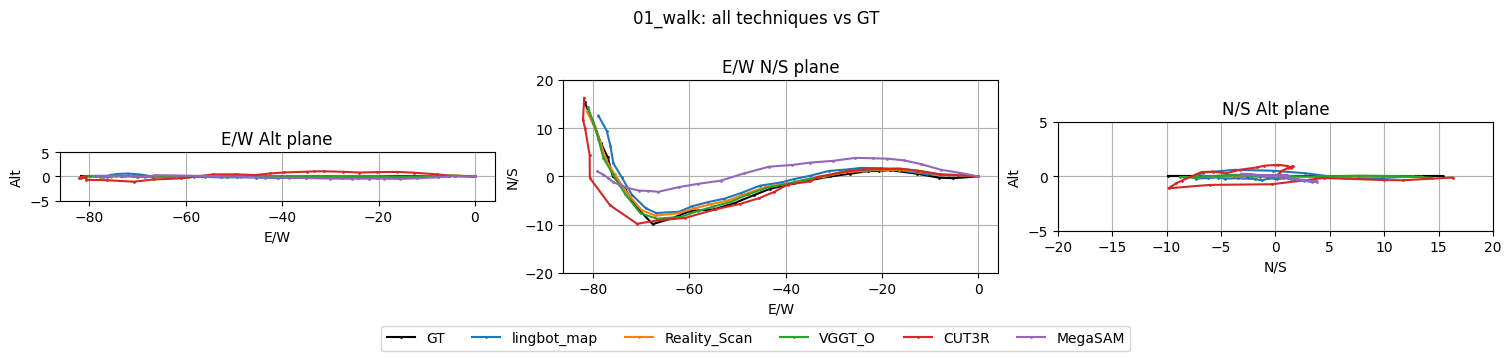

In [27]:
from matplotlib import pyplot as plt
def ortho_charts_multi(gt, traces, title="All techniques vs GT", out_path=None,
                        axis_lims={1: 5, 2: 20}):
    views = [("E/W", "Alt", 0, 1), ("E/W", "N/S", 0, 2), ("N/S", "Alt", 2, 1)]
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), constrained_layout=True)
    colors = plt.cm.tab10.colors
    dot_size = 1
    for ax, (xl, yl, xi, yi) in zip(axes, views):
        ax.plot(gt[:, xi], gt[:, yi], "o-", color="black", label="GT", markersize=dot_size)
        for i, (label, pts) in enumerate(traces.items()):
            ax.plot(pts[:, xi], pts[:, yi], "o-", color=colors[i % len(colors)], label=label, markersize=dot_size)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(f"{xl} {yl} plane")
        if xi in axis_lims:
            ax.set_xlim(-axis_lims[xi], axis_lims[xi])
        if yi in axis_lims:
            ax.set_ylim(-axis_lims[yi], axis_lims[yi])
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
    fig.suptitle(title)
    if out_path is not None:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()




ortho_charts_multi(
    gt_trace, aligned_traces,
    title=f"{case_name}: all techniques vs GT",
    out_path=out_dir / f"{case_name}_all_techniques_combined.png",
)


50 frames
trajectory length: 2.1119623
bbox min: [-3.9310843e-01 -2.1711837e-01 -3.6794510e-05]  max: [ 2.0484176e-05 -2.3400440e-05  1.2968507e+00]


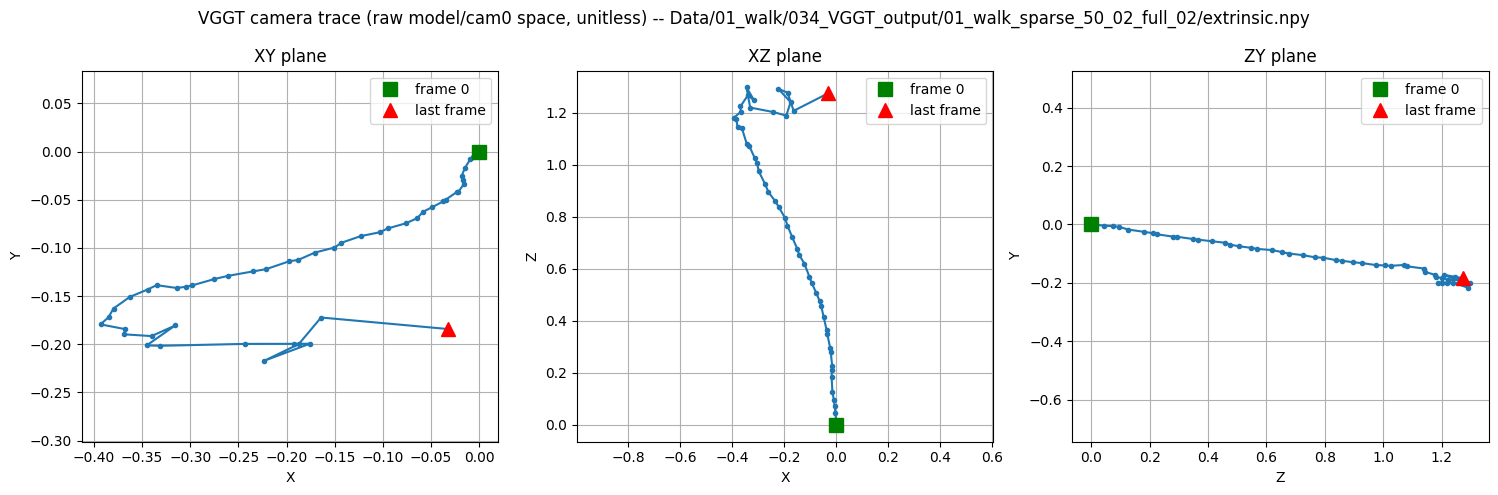

In [28]:
#VGGT sanity check
import numpy as np
import matplotlib.pyplot as plt

path = "Data/01_walk/034_VGGT_output/01_walk_sparse_50_02_full_02/extrinsic.npy"

d = np.load(path)  # (N, 3, 4), world-to-camera
R = d[:, :3, :3]
t = d[:, :3, 3]
Rt = np.transpose(R, (0, 2, 1))
pos = -np.einsum("nij,nj->ni", Rt, t)  # camera centres in world/model space

print(f"{len(pos)} frames")
print("trajectory length:", np.sum(np.linalg.norm(np.diff(pos, axis=0), axis=1)))
print("bbox min:", pos.min(axis=0), " max:", pos.max(axis=0))

views = [("X", "Y", 0, 1), ("X", "Z", 0, 2), ("Z", "Y", 2, 1)]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (xl, yl, xi, yi) in zip(axes, views):
    ax.plot(pos[:, xi], pos[:, yi], "o-", color="tab:blue", markersize=3)
    ax.plot(pos[0, xi], pos[0, yi], "s", color="green", markersize=10, label="frame 0")
    ax.plot(pos[-1, xi], pos[-1, yi], "^", color="red", markersize=10, label="last frame")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"{xl}{yl} plane")
    ax.set_aspect("equal", adjustable="datalim")  # square cells
    ax.grid(True)
    ax.legend()
fig.suptitle(f"VGGT camera trace (raw model/cam0 space, unitless) -- {path}")
fig.tight_layout()


{0: array([ 6.15798490e-05, -2.77518047e-05,  1.09068846e-04], dtype=float32), 56: array([-0.00158485, -0.00334001,  0.03929828], dtype=float32), 98: array([-0.00594916, -0.00527186,  0.06593461], dtype=float32), 147: array([-0.01111917, -0.00947439,  0.09915568], dtype=float32), 189: array([-0.01445108, -0.01772284,  0.12951776], dtype=float32), 245: array([-0.01868266, -0.02358501,  0.16485403], dtype=float32), 294: array([-0.01759701, -0.02776501,  0.20124747], dtype=float32), 343: array([-0.01658423, -0.03456071,  0.2296929 ], dtype=float32), 392: array([-0.01979593, -0.03913959,  0.26809242], dtype=float32), 438: array([-0.02446026, -0.04244877,  0.2980016 ], dtype=float32), 490: array([-0.03160151, -0.04641109,  0.32892326], dtype=float32), 539: array([-0.03848423, -0.0507668 ,  0.3614173 ], dtype=float32), 591: array([-0.04511884, -0.05707049,  0.40369624], dtype=float32), 637: array([-0.05598274, -0.058313  ,  0.43374786], dtype=float32), 686: array([-0.06141047, -0.06775254,  

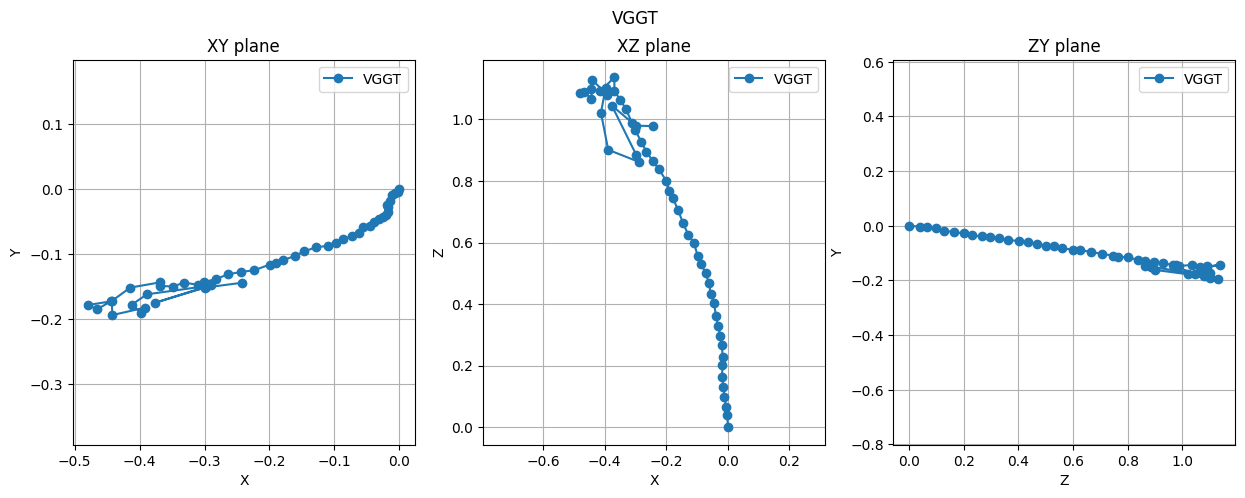

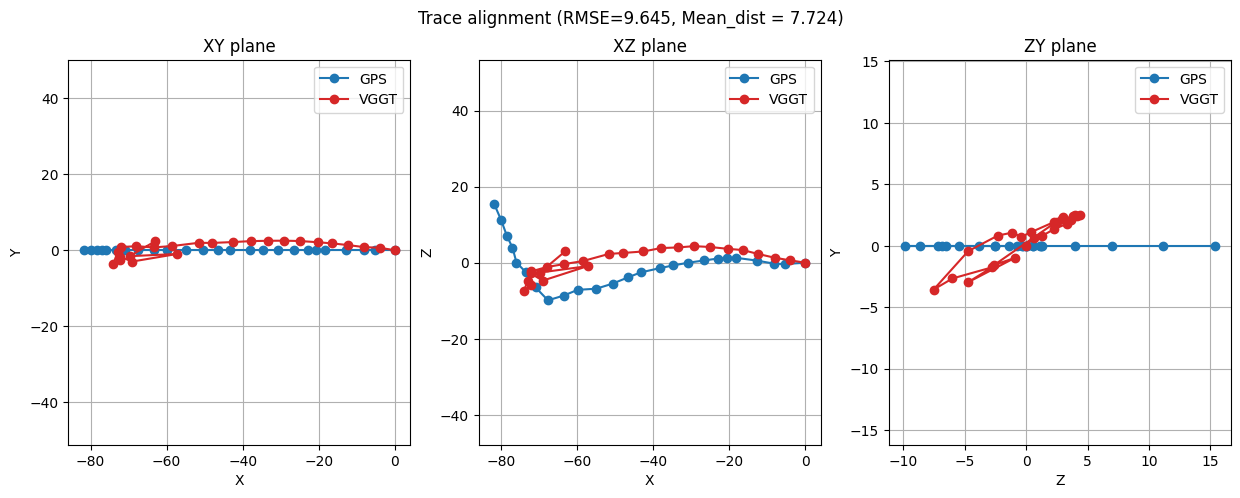

In [29]:
from F_post_recon_processing import load_VGGT_trace
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
test , test_dict = load_VGGT_trace(case_dir/"034_VGGT_output"/"walk_sweeps_short"/"poses_0050", frames_dir = case_dir/"020_frames_for_cam_poses"/"walk_sweeps_short"/"poses_0050")
print(test_dict)
csv_path_GPS = case_dir  / "000_GPS_Data" / "GPS_tags.csv"
print(csv_path_GPS)
VGGT_world, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, test_dict, Source = "VGGT" )

{0: array([ 6.15798490e-05, -2.77518047e-05,  1.09068846e-04], dtype=float32), 56: array([-0.00158485, -0.00334001,  0.03929828], dtype=float32), 98: array([-0.00594916, -0.00527186,  0.06593461], dtype=float32), 147: array([-0.01111917, -0.00947439,  0.09915568], dtype=float32), 189: array([-0.01445108, -0.01772284,  0.12951776], dtype=float32), 245: array([-0.01868266, -0.02358501,  0.16485403], dtype=float32), 294: array([-0.01759701, -0.02776501,  0.20124747], dtype=float32), 343: array([-0.01658423, -0.03456071,  0.2296929 ], dtype=float32), 392: array([-0.01979593, -0.03913959,  0.26809242], dtype=float32), 438: array([-0.02446026, -0.04244877,  0.2980016 ], dtype=float32), 490: array([-0.03160151, -0.04641109,  0.32892326], dtype=float32), 539: array([-0.03848423, -0.0507668 ,  0.3614173 ], dtype=float32), 591: array([-0.04511884, -0.05707049,  0.40369624], dtype=float32), 637: array([-0.05598274, -0.058313  ,  0.43374786], dtype=float32), 686: array([-0.06141047, -0.06775254,  

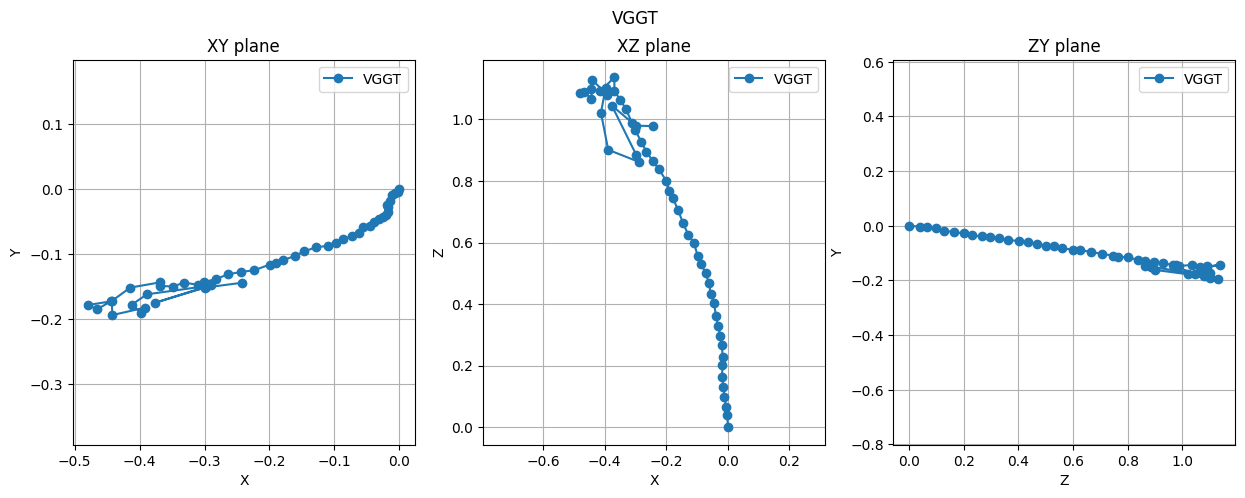

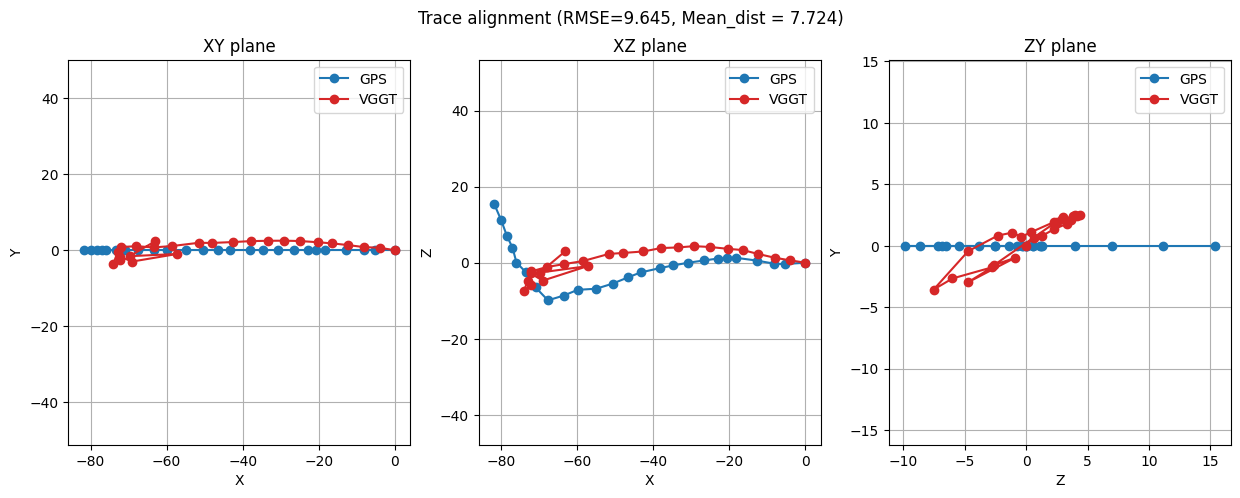

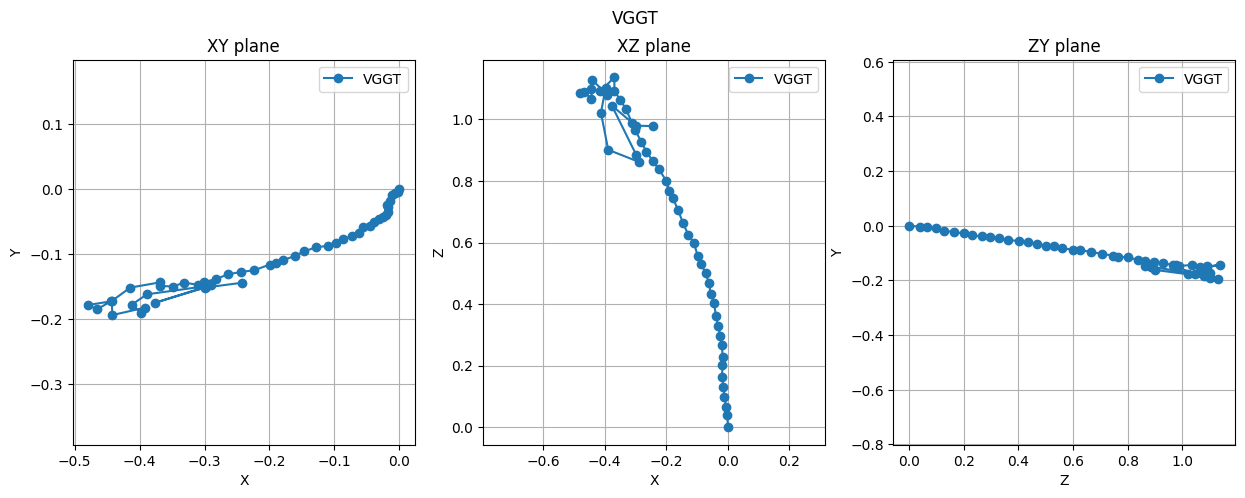

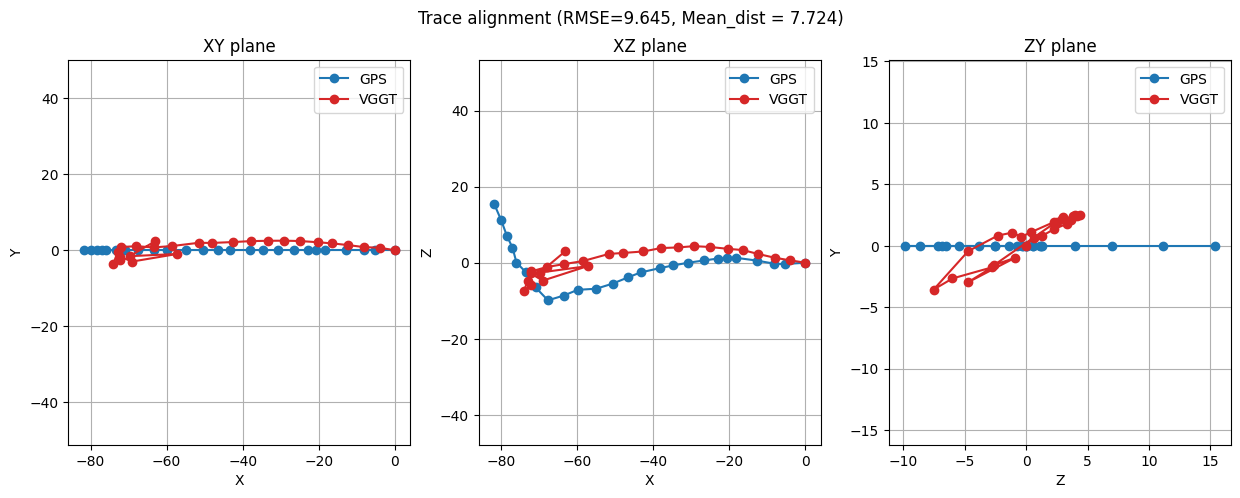

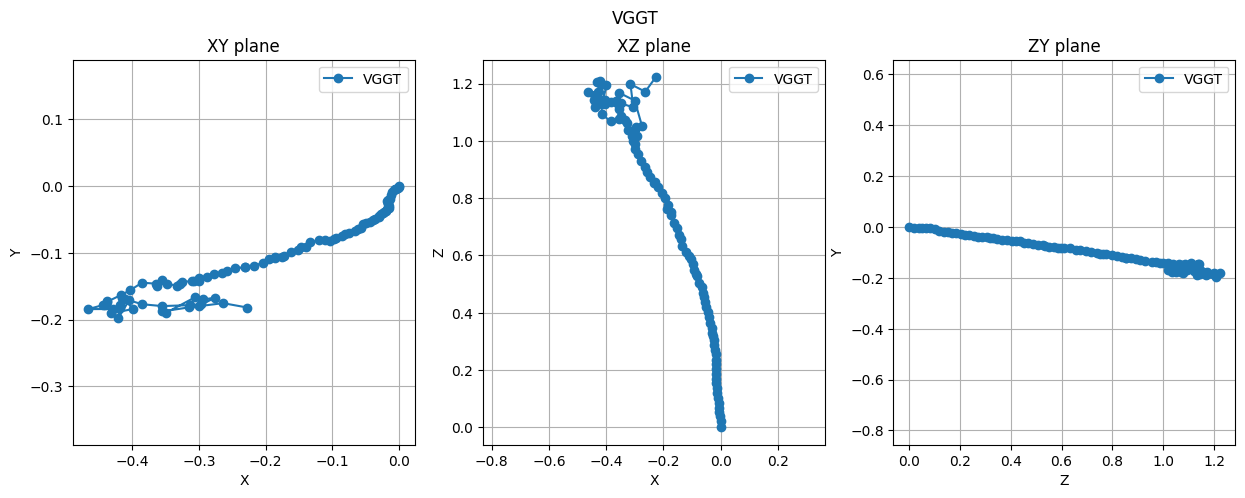

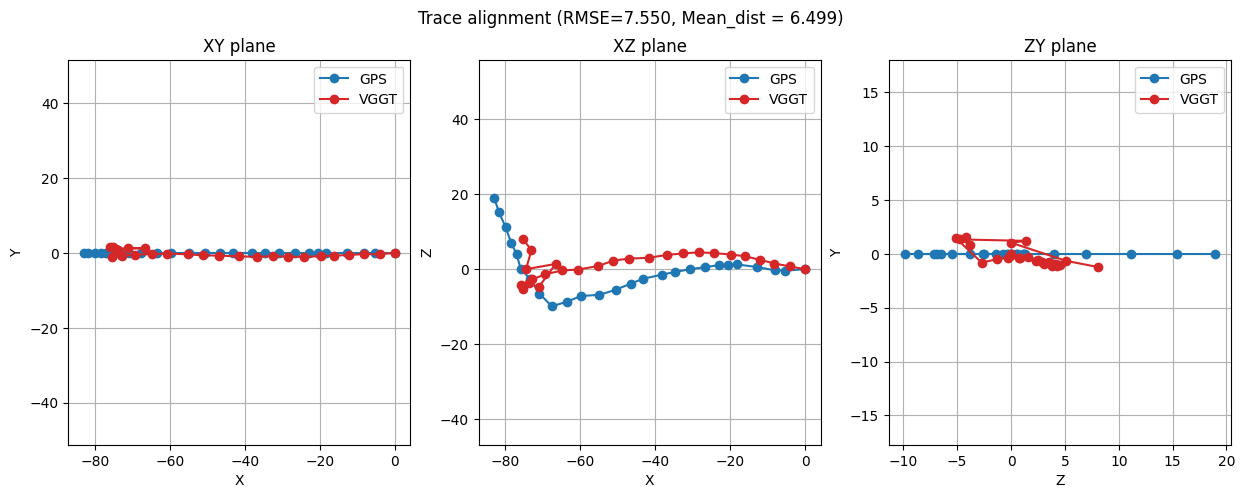

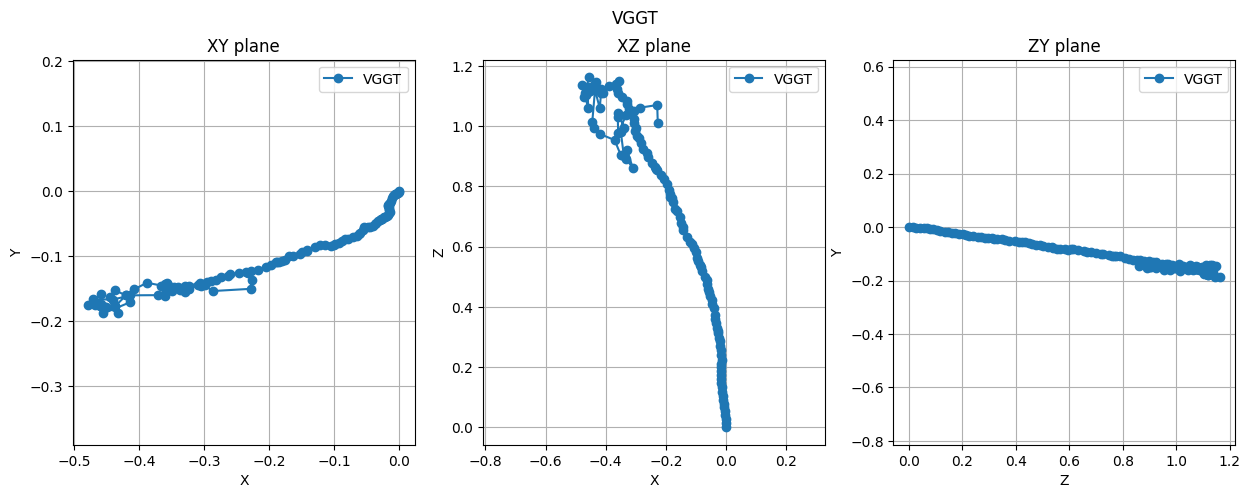

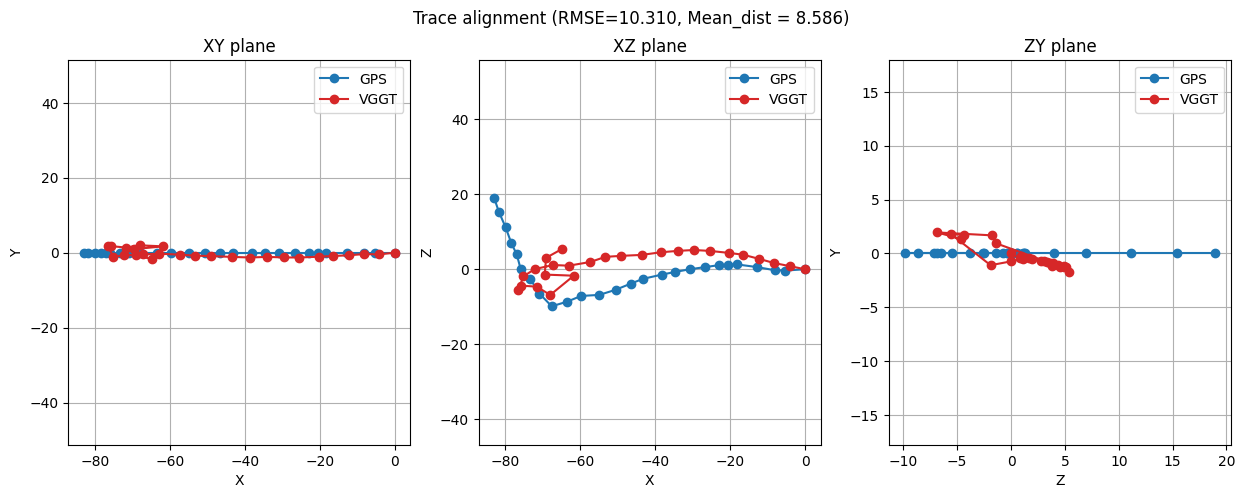

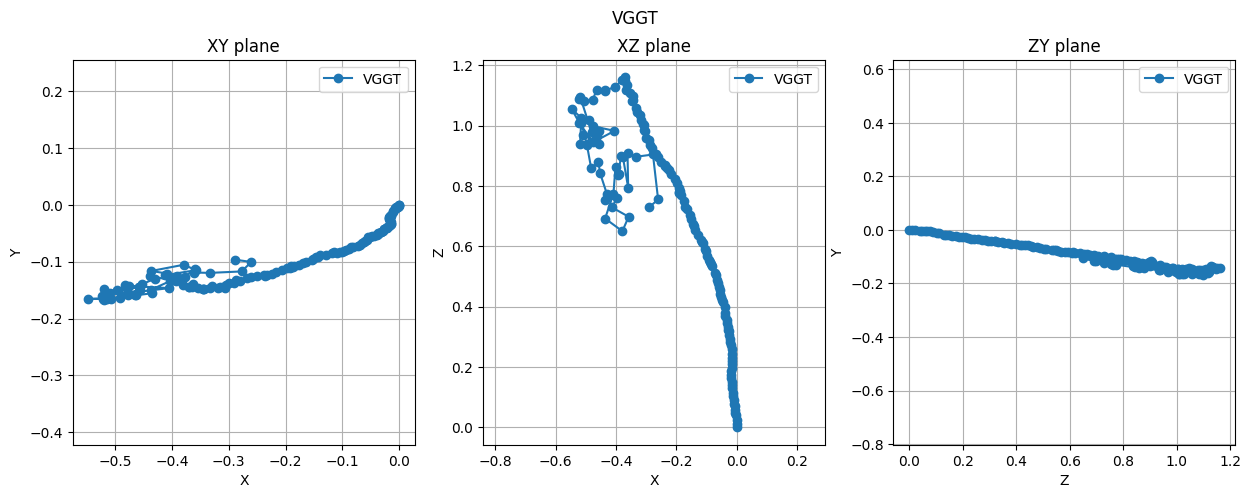

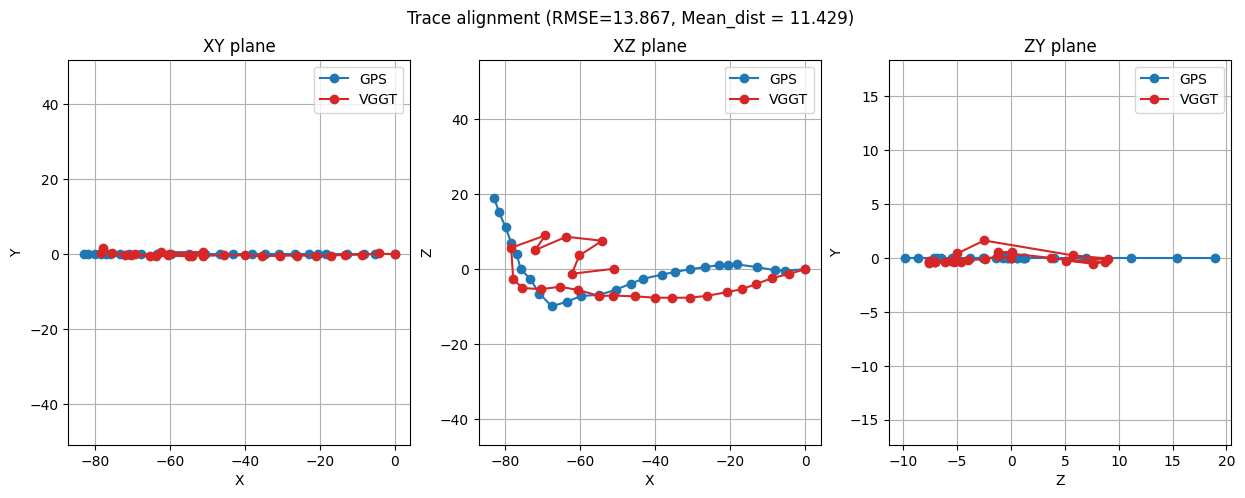

In [30]:
from F_post_recon_processing import load_VGGT_trace
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
test , test_dict = load_VGGT_trace(case_dir/"034_VGGT_output"/"walk_sweeps_short"/"poses_0050", frames_dir = case_dir/"020_frames_for_cam_poses"/"walk_sweeps_short"/"poses_0050")
print(test_dict)
csv_path_GPS = case_dir  / "000_GPS_Data" / "GPS_tags.csv"
print(csv_path_GPS)
VGGT_world, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, test_dict, Source = "VGGT" )
test , test_dict = load_VGGT_trace(case_dir/"034_VGGT_output"/"walk_sweeps_short"/"poses_0050", frames_dir = case_dir/"020_frames_for_cam_poses"/"walk_sweeps_short"/"poses_0050")
VGGT_world, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, test_dict, Source = "VGGT" )
test , test_dict = load_VGGT_trace(case_dir/"034_VGGT_output"/"walk_sweeps_short"/"poses_0100", frames_dir = case_dir/"020_frames_for_cam_poses"/"walk_sweeps_short"/"poses_0100")
VGGT_world, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, test_dict, Source = "VGGT" )
test , test_dict = load_VGGT_trace(case_dir/"034_VGGT_output"/"walk_sweeps_short"/"poses_0125", frames_dir = case_dir/"020_frames_for_cam_poses"/"walk_sweeps_short"/"poses_0125")
VGGT_world, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, test_dict, Source = "VGGT" )
test , test_dict = load_VGGT_trace(case_dir/"034_VGGT_output"/"walk_sweeps_short"/"poses_0150", frames_dir = case_dir/"020_frames_for_cam_poses"/"walk_sweeps_short"/"poses_0150")
VGGT_world, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, test_dict, Source = "VGGT" )
